# Slide tables — May Presentation

> **Note:** V2.6 is treated as the **full model** here (toggleable via `FULL_VERSION` in the setup cell) — all global posteriors, region rank, phase, amplitude, and pairwise tables are sourced from `data/models/wide_weekly_scaledPer10k/{FULL_VERSION}/`. The DIC comparison and the V2.5-vs-V2.6 MW-reset comparison are the only cells that pin a specific version.

Pattern (mirrors `formula/v4_1_slide_formulas.ipynb`):

1. Pull data from `data/models/{stem}/{version}/*.csv`
2. Format with `pandas.Styler` -> emit `\begin{tabular}` LaTeX via `to_latex(hrules=True)`
3. Wrap in a `standalone` preamble, write `.tex` next to this notebook
4. Shell out to `latexmk` -- the `.latexmkrc` hook produces `rendered/<name>.png` and `.svg`
5. Display the PNG inline for proofing

Drag the resulting PNG (or SVG) into Google Slides.

In [38]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# Resolve project root by walking up to CLAUDE.md
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CLAUDE.md').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLES_DIR = PROJECT_ROOT / 'May_Presentation' / 'tables'
RENDERED   = TABLES_DIR / 'rendered'
MODELS_DIR = PROJECT_ROOT / 'data' / 'models' / 'wide_weekly_scaledPer10k'
RENDERED.mkdir(parents=True, exist_ok=True)

# Default "full model" for all baseline/cycle/NY/trace/Gelman cells.
# The V2.5 vs V2.6 MW-reset comparison cells override this locally.
FULL_VERSION = 'v2.6'

PREAMBLE = r'''\documentclass[varwidth=24cm,border=14pt]{standalone}
\usepackage{booktabs, siunitx}
\sisetup{table-format=4.1, group-separator={,}}
\begin{document}
'''
POSTAMBLE = r'''
\end{document}
'''

LATEXMK = '/opt/homebrew/bin/latexmk'


_LATEX_ESCAPES = {
    '\\': r'\textbackslash{}',
    '&':  r'\&',
    '%':  r'\%',
    '$':  r'\$',
    '#':  r'\#',
    '_':  r'\_',
    '{':  r'\{',
    '}':  r'\}',
    '~':  r'\textasciitilde{}',
    '^':  r'\textasciicircum{}',
}

def latex_escape(s):
    """Escape LaTeX special characters in a string."""
    s = str(s)
    for k, v in _LATEX_ESCAPES.items():
        s = s.replace(k, v)
    return s

def escape_df(df):
    """Return a copy of df with all string cells + column headers LaTeX-escaped."""
    out = df.copy()
    out.columns = [latex_escape(c) for c in out.columns]
    for col in out.select_dtypes(include='object').columns:
        out[col] = out[col].map(latex_escape)
    return out


def render_table(name: str, body: str):
    """Wrap body in standalone preamble, write .tex, build, display PNG."""
    tex_path = TABLES_DIR / f'{name}.tex'
    tex_path.write_text(PREAMBLE + body + POSTAMBLE)
    res = subprocess.run(
        [LATEXMK, '-cd', '-pdf', '-interaction=nonstopmode', str(tex_path)],
        capture_output=True, text=True,
    )
    if res.returncode != 0:
        print('STDOUT:', res.stdout[-2000:])
        print('STDERR:', res.stderr[-2000:])
        raise RuntimeError(f'latexmk failed for {name}')
    png = RENDERED / f'{name}.png'
    display(Image(str(png)))
    print(f'OK -> {png.relative_to(PROJECT_ROOT)}')


def render_plot(name: str, fig):
    """Save matplotlib figure to RENDERED/<name>.png and display inline."""
    png = RENDERED / f'{name}.png'
    fig.savefig(png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(str(png)))
    print(f'OK -> {png.relative_to(PROJECT_ROOT)}')

## DIC comparison across model versions

Stacks the single-row `dic.csv` from each model output.

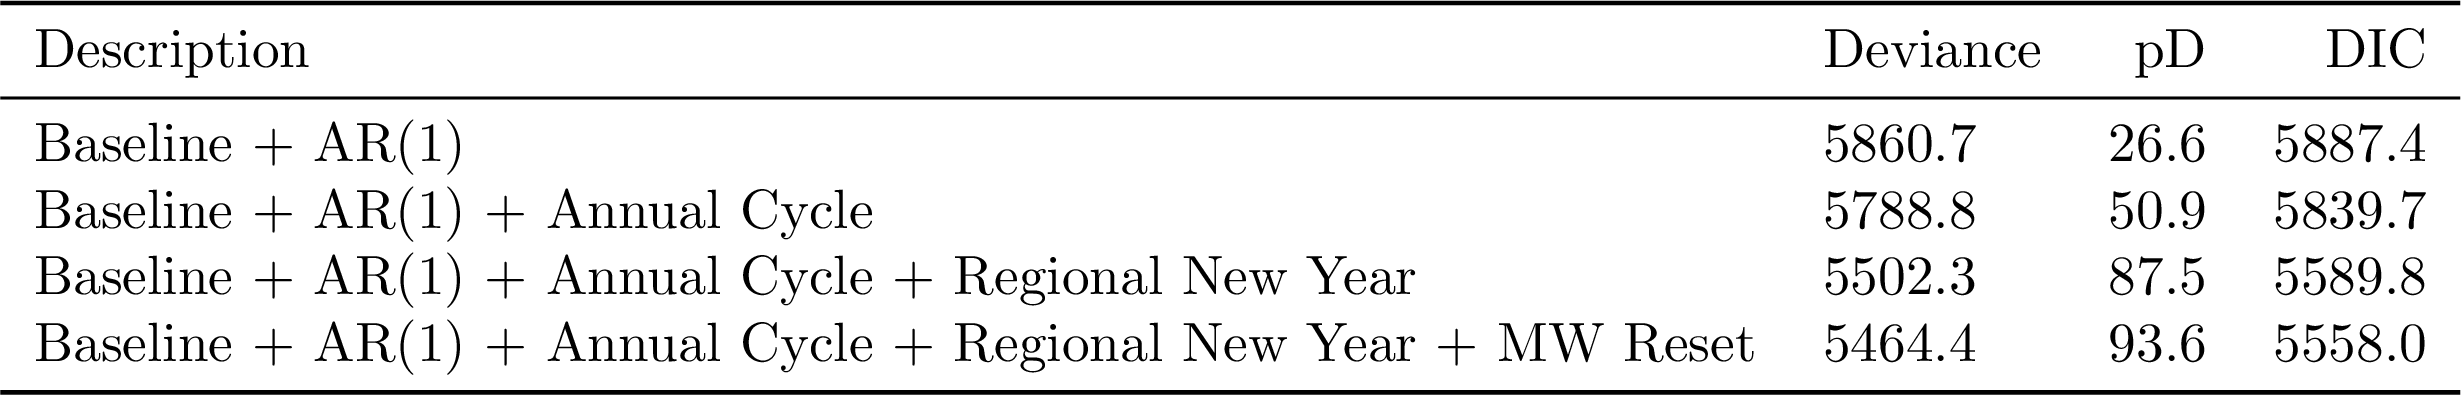

OK -> May_Presentation/tables/rendered/dic_comparison.png


In [39]:
versions = ['v0.1', 'v1.1', 'v2.3','v2.5']

rows = [pd.read_csv(MODELS_DIR / v / 'dic.csv').iloc[0] for v in versions]
df = pd.DataFrame(rows)[['description', 'deviance', 'penalty', 'DIC']]
df.columns = ['Description', 'Deviance', 'pD', 'DIC']

body = (df.style
        .format({'Deviance': '{:.1f}', 'pD': '{:.1f}', 'DIC': '{:.1f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrrr'))

render_table('dic_comparison', body)

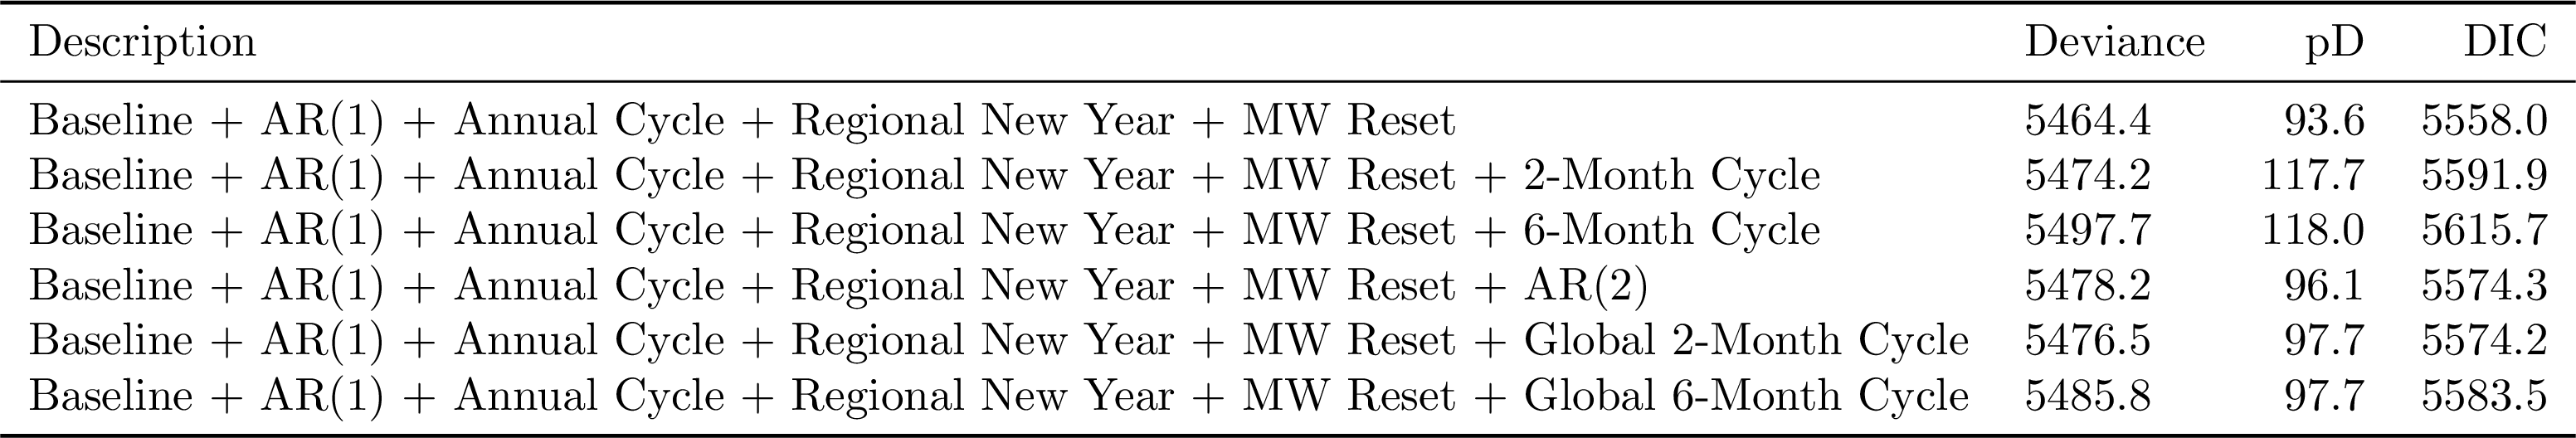

OK -> May_Presentation/tables/rendered/dic_comparison.png


In [40]:
versions = ['v2.5','v3.1','v3.2','v3.3', 'v3.4', 'v3.5']

rows = [pd.read_csv(MODELS_DIR / v / 'dic.csv').iloc[0] for v in versions]
df = pd.DataFrame(rows)[['description', 'deviance', 'penalty', 'DIC']]
df.columns = ['Description', 'Deviance', 'pD', 'DIC']

body = (df.style
        .format({'Deviance': '{:.1f}', 'pD': '{:.1f}', 'DIC': '{:.1f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrrr'))

render_table('dic_comparison', body)

## DIC comparison: V2.1 vs global sub-annual cycles (V3.4, V3.5)

V3.4 adds a **global** 2-month cycle to V2.1; V3.5 adds a **global** 6-month cycle. Both pool the sub-annual harmonic across regions (single scalar amplitude/phase) rather than fitting one per region. Lower DIC = better predictive fit after penalising effective parameters (pD).

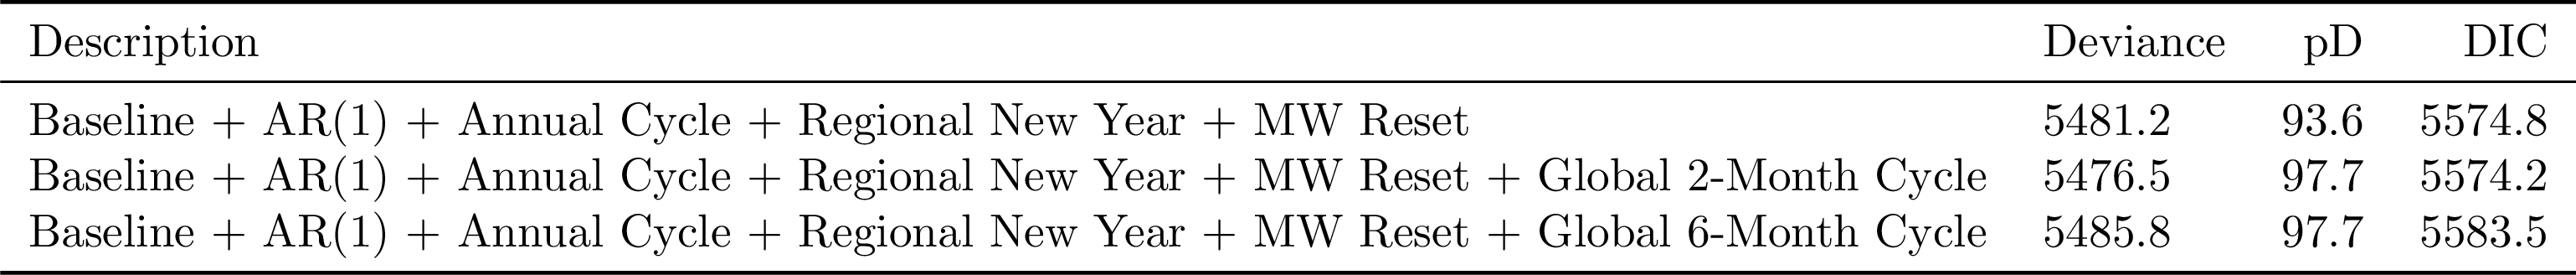

OK -> May_Presentation/tables/rendered/dic_comparison_global_cycles.png


In [41]:
versions = ['v2.1', 'v3.4', 'v3.5']

rows = [pd.read_csv(MODELS_DIR / v / 'dic.csv').iloc[0] for v in versions]
df = pd.DataFrame(rows)[['description', 'deviance', 'penalty', 'DIC']]
df.columns = ['Description', 'Deviance', 'pD', 'DIC']

body = (df.style
        .format({'Deviance': '{:.1f}', 'pD': '{:.1f}', 'DIC': '{:.1f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrrr'))

render_table('dic_comparison_global_cycles', body)

## DIC comparison: V2.1 vs V2.6 (extended MW reset window)

V2.6 extends V2.1's MW reset from 3 weekly indicators to 5 (3 reset weeks + 2 post-reset weeks) under the corrected Monday-start week alignment for Aug 5 – Sep 8 2024.

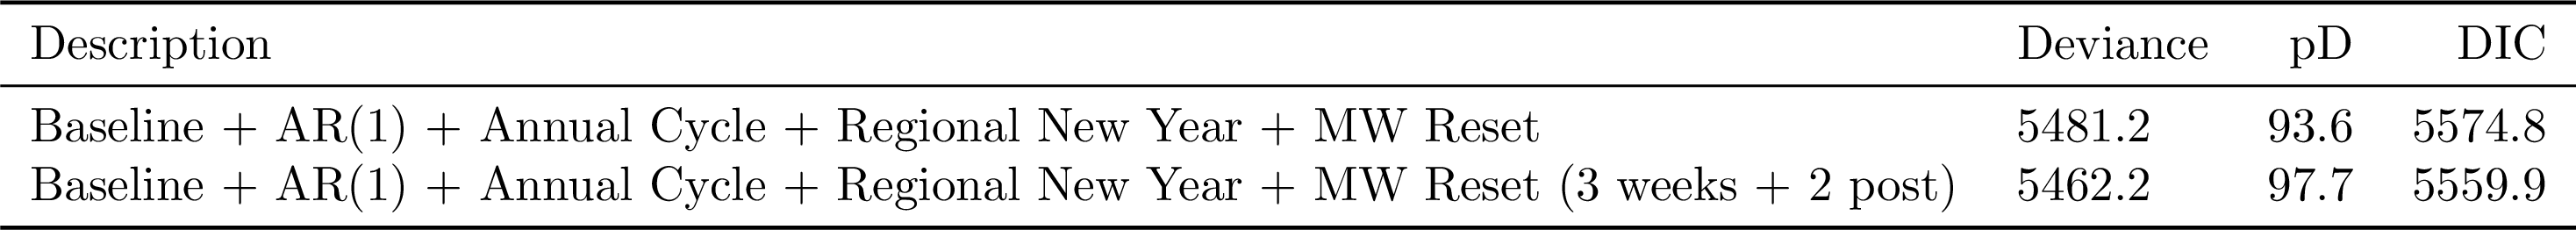

OK -> May_Presentation/tables/rendered/dic_comparison_v21_v26.png


In [42]:
versions = ['v2.1', 'v2.6']

rows = [pd.read_csv(MODELS_DIR / v / 'dic.csv').iloc[0] for v in versions]
df = pd.DataFrame(rows)[['description', 'deviance', 'penalty', 'DIC']]
df.columns = ['Description', 'Deviance', 'pD', 'DIC']

body = (df.style
        .format({'Deviance': '{:.1f}', 'pD': '{:.1f}', 'DIC': '{:.1f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrrr'))

render_table('dic_comparison_v21_v26', body)

## Global parameter posterior summary

Reads `global_parameters.csv` -- the truly global scalars with mean and 95% CI. The MW reset effects (`sigma_*`) are filtered out because they only act on the Mid-West and have their own table in the **Mid-West full reset effect** section below.

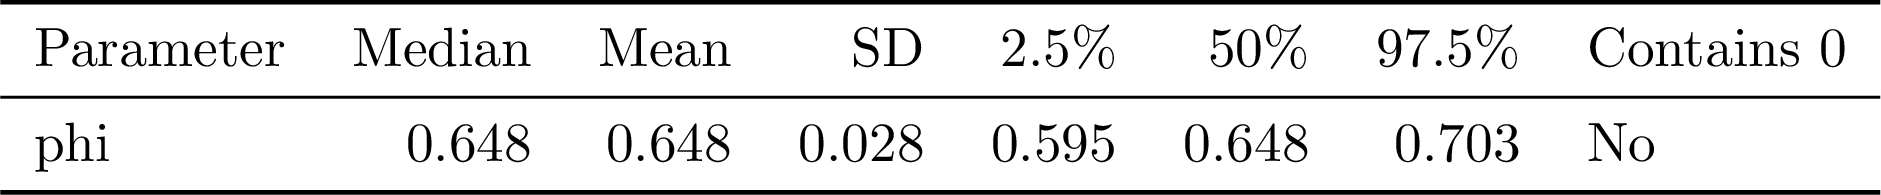

OK -> May_Presentation/tables/rendered/global_params_v26.png


In [43]:
g = pd.read_csv(MODELS_DIR / FULL_VERSION / 'global_parameters.csv')
# Drop MW reset effects -- shown in the Mid-West full reset section instead.
g = g[~g['Parameter'].str.startswith('sigma_')].reset_index(drop=True)
g['Contains 0'] = g.apply(lambda r: 'Yes' if r['2.5%'] <= 0 <= r['97.5%'] else 'No', axis=1)
g = escape_df(g)  # parameter names contain '_'; column headers contain '%'

body = (g.style
        .format(precision=3)
        .hide(axis='index')
        .to_latex(hrules=True, column_format='l' + 'r' * (len(g.columns) - 2) + 'l'))

render_table(f'global_params_{FULL_VERSION.replace(".", "")}', body)

## Global parameter posterior summary — math symbols

Same data, but parameter names mapped to their LaTeX math symbols so the table reads like the model formula. Compare against the table above.

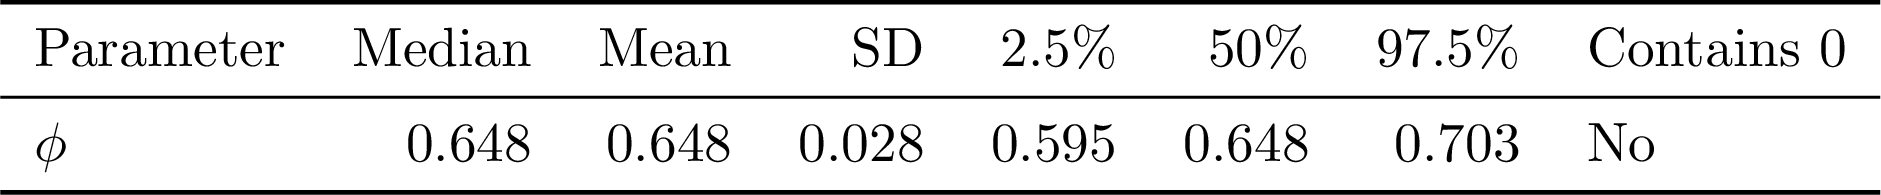

OK -> May_Presentation/tables/rendered/global_params_v26_symbols.png


In [44]:
PARAM_LABELS = {
    'alpha':      r'$\alpha$',
    'beta':       r'$\beta$',
    'gamma':      r'$\gamma$',
    'delta_pre':  r'$\delta_{\text{pre}}$',
    'delta_mid':  r'$\delta_{\text{mid}}$',
    'delta_post': r'$\delta_{\text{post}}$',
    'sigma_pre':  r'$\sigma_{\text{pre}}$',
    'sigma_mid':  r'$\sigma_{\text{mid}}$',
    'sigma_post': r'$\sigma_{\text{post}}$',
    'phi':        r'$\phi$',
    'tau':        r'$\tau$',
    'mu_alpha':   r'$\mu_\alpha$',
    'tau_alpha':  r'$\tau_\alpha$',
}

g = pd.read_csv(MODELS_DIR / FULL_VERSION / 'global_parameters.csv')
# Drop MW reset effects -- shown in the Mid-West full reset section instead.
g = g[~g['Parameter'].str.startswith('sigma_')].reset_index(drop=True)
g['Contains 0'] = g.apply(lambda r: 'Yes' if r['2.5%'] <= 0 <= r['97.5%'] else 'No', axis=1)
# Map parameter names to math symbols (fall back to escaped raw name)
g['Parameter'] = g['Parameter'].map(lambda p: PARAM_LABELS.get(p, latex_escape(p)))
# Escape the rest (column headers contain '%')
g.columns = [latex_escape(c) for c in g.columns]

body = (g.style
        .format(precision=3)
        .hide(axis='index')
        .to_latex(hrules=True, column_format='l' + 'r' * (len(g.columns) - 2) + 'l'))

render_table(f'global_params_{FULL_VERSION.replace(".", "")}_symbols', body)

## Region rank stability test

For each region's posterior intercept $\alpha_i$:

1. Compute its rank within the 6 regions on every posterior sample.
2. Median rank and 95% CI on rank summarise the rank distribution.
3. **Test:** a region is *distinctly ranked* if no other region's median rank lies inside its 95% CI.

Computed from existing `raw_samples.csv` — no re-fit needed.


=== wide_weekly_scaledPer10k (v2.6) ===
                   Region  Ranked Mean  Mean Rank  Median Rank 95% CI
HSE Dublin and North East          1.0   1.000000            1 [1, 1]
HSE Dublin and South East          2.0   2.000200            2 [2, 2]
  HSE Dublin and Midlands          3.0   3.015175            3 [3, 3]
           HSE South West          4.0   3.984625            4 [4, 4]
  HSE West and North West          5.0   5.000075            5 [5, 5]
             HSE Mid West          6.0   5.999925            6 [6, 6]


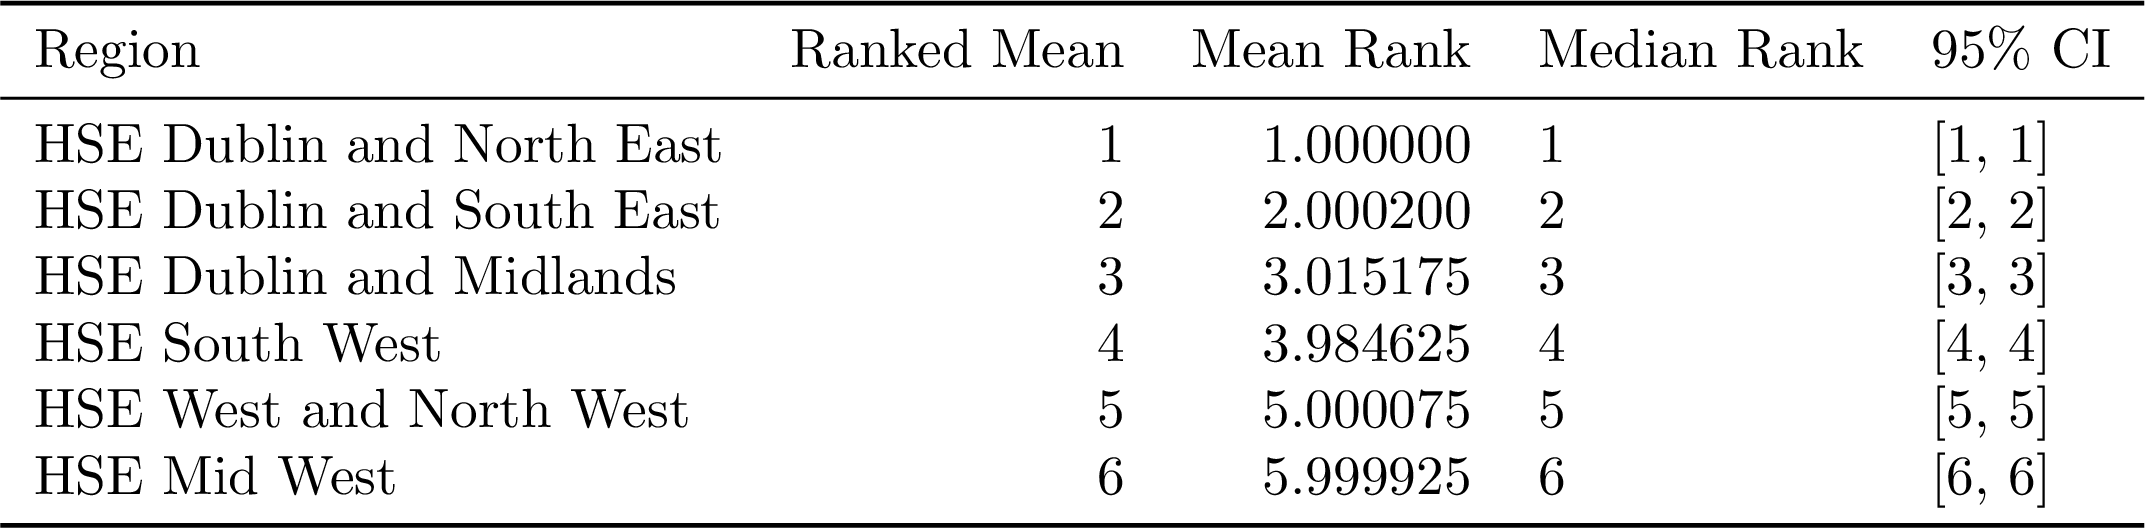

OK -> May_Presentation/tables/rendered/alpha_rank_test_wide_weekly_scaledPer10k_v26.png
SKIP wide_weekly_scaledPer1kOver65: missing inputs
SKIP wide_weekly_scaledPerBed: missing inputs
SKIP wide_weekly_scaledPerBudgetThousands: missing inputs


In [45]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from pyjags_pipeline.significance import build_ranked_alpha
from pyjags_pipeline.data import load_observed

SCALINGS = [
    'wide_weekly_scaledPer10k',
    'wide_weekly_scaledPer1kOver65',
    'wide_weekly_scaledPerBed',
    'wide_weekly_scaledPerBudgetThousands',
]
RANK_VERSION = FULL_VERSION

# Cache for downstream cells (keyed by scaling stem)
rank_inputs = {}

for stem in SCALINGS:
    samples_path = PROJECT_ROOT / 'data' / 'models' / stem / RANK_VERSION / 'raw_samples.csv'
    input_csv = PROJECT_ROOT / 'data' / f'{stem}.csv'
    if not samples_path.exists() or not input_csv.exists():
        print(f'SKIP {stem}: missing inputs')
        continue

    # Region order from this scaling's input CSV — must match alpha[1..6] in raw_samples
    _, regions, _, _, _ = load_observed(f'data/{stem}.csv')

    raw = pd.read_csv(samples_path)
    ranked = build_ranked_alpha(raw, regions)  # (n_samples, n_region) ranks 1..6

    summary = pd.DataFrame({
        'Region':      regions,
        'Ranked Mean': ranked.mean(axis=0).rank().values,
        'Mean Rank':   ranked.mean(axis=0).values,
        'Median Rank': ranked.median(axis=0).round().astype(int).values,
        '2.5%':        ranked.quantile(0.025, axis=0).values,
        '97.5%':       ranked.quantile(0.975, axis=0).values,
    })
    summary['95% CI'] = summary.apply(
        lambda r: f"[{r['2.5%']:.0f}, {r['97.5%']:.0f}]", axis=1)

    display_df = (summary
                  .sort_values(['Ranked Mean'])
                  [['Region', 'Ranked Mean', 'Mean Rank', 'Median Rank', '95% CI']]
                  .reset_index(drop=True))

    print(f'\n=== {stem} ({RANK_VERSION}) ===')
    print(display_df.to_string(index=False))

    rank_inputs[stem] = {'raw': raw, 'regions': regions}

    body = (escape_df(display_df).style
            .format({'Ranked Mean': '{:.0f}'})
            .hide(axis='index')
            .to_latex(hrules=True, column_format='lrrll'))

    render_table(f'alpha_rank_test_{stem}_{RANK_VERSION.replace(".", "")}', body)

# Preserve `raw` and `regions` for the per10k scaling so downstream phase cells still work
raw, regions = rank_inputs['wide_weekly_scaledPer10k']['raw'], rank_inputs['wide_weekly_scaledPer10k']['regions']

## Phase test: does the cycle peak align with New Year?

$$\theta_i = \frac{52}{2\pi}\,\operatorname{atan2}(\gamma_i,\, \beta_i) \pmod{52}$$

For each region's annual cycle ($\beta_i \cos + \gamma_i \sin$), each posterior sample gives a peak week. Phase is **circular data** so all summary statistics use circular formulas (Berens 2009, https://doi.org/10.18637/jss.v031.i10).

Reported per region:

- **Circular mean peak (week)** — direction-vector average; immune to wrap-around at week 0/52
- **95% HPD arc** — shortest arc on the circle containing 95% of posterior samples
- **P(within 2w of NY)**, **P(within 4w of NY)** — direct posterior probability that the peak is within ±2 / ±4 weeks of week 0

A region whose **P(within 2w) is high** has a cycle peak decisively at New Year — the explicit $\delta_{\text{pre/mid/post}}$ deltas are then *additional* signal on top of the cycle.

                   Region  Mean peak (wk from NY) 95% CI (wk from NY)  Width (wk)  P(within 2mo of NY)
HSE Dublin and North East                1.639730        [-2.6, +5.8]    8.426592             0.998350
HSE Dublin and South East                1.962479        [-2.5, +6.7]    9.208857             0.995237
           HSE South West                2.546448        [-2.6, +7.7]   10.326761             0.985888
  HSE Dublin and Midlands                5.686886       [+0.2, +11.1]   10.959737             0.868225
  HSE West and North West                5.387015       [-7.7, +19.6]   27.352238             0.705838
             HSE Mid West               18.968643       [-2.6, +41.0]   43.559844             0.158225


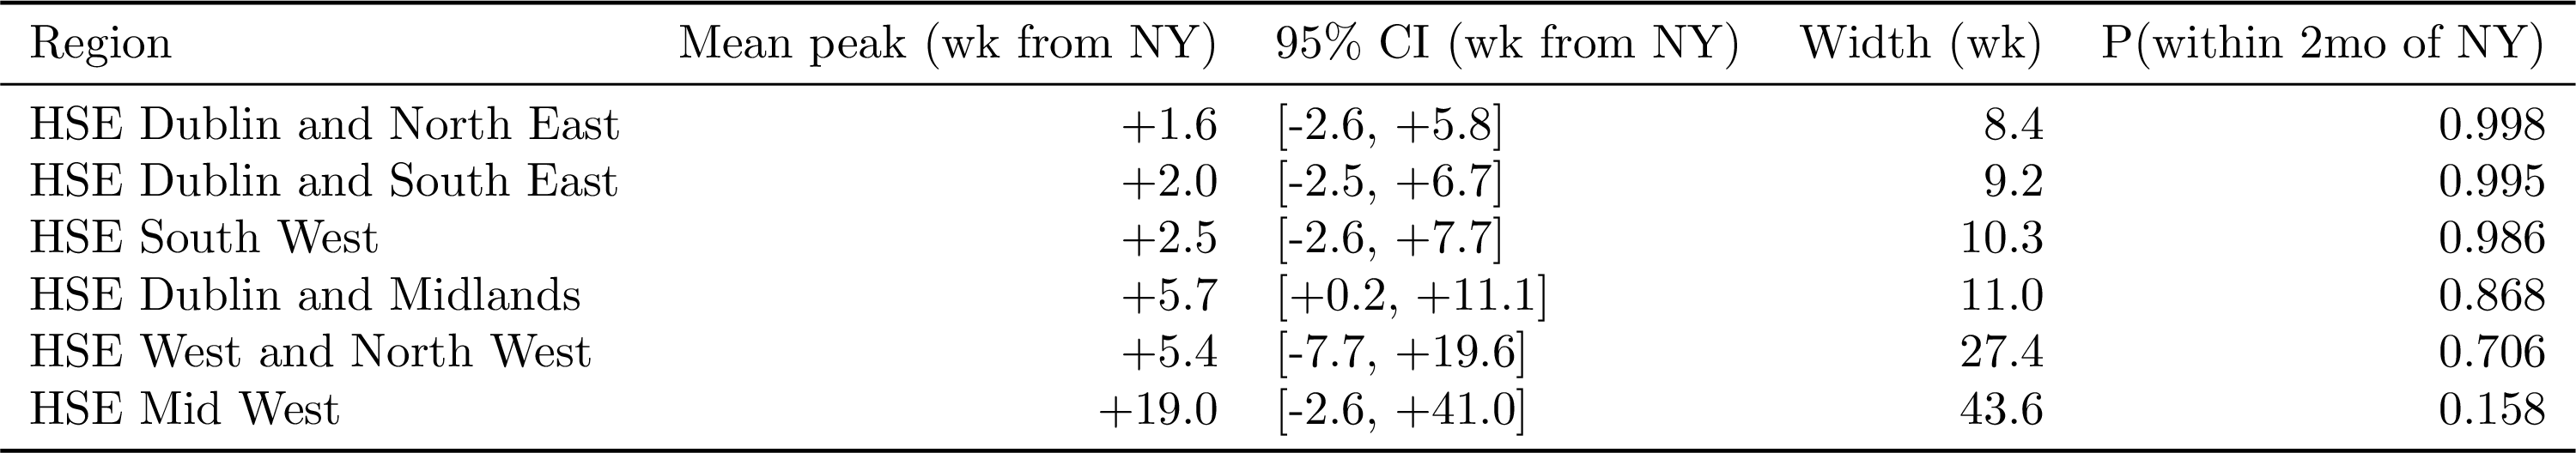

OK -> May_Presentation/tables/rendered/phase_ny_test_v26.png


In [59]:
import numpy as np
from pyjags_pipeline.significance import compute_phase

PERIOD = 52
NY_WEEK = 0
WEEKS_PER_MONTH = PERIOD / 12  # 4.333…

def circular_mean(samples, period=PERIOD):
    """Direction-vector mean of samples on a circle of given period."""
    rad = 2 * np.pi * samples / period
    mean_rad = np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))
    return (period * mean_rad / (2 * np.pi)) % period

def circular_distance(w, ref, period=PERIOD):
    """Shortest distance on a circle from w to ref."""
    d = np.abs(w - ref) % period
    return np.minimum(d, period - d)

def circular_hpd(samples, prob=0.95, period=PERIOD):
    """Shortest arc on the circle containing `prob` fraction of samples.
    Returns (lo, hi) where the arc goes from lo to hi clockwise (may wrap)."""
    s = np.sort(samples)
    n = len(s)
    k = int(np.ceil(prob * n))
    extended = np.concatenate([s, s + period])
    arcs = extended[k - 1:k - 1 + n] - extended[:n]
    i = int(np.argmin(arcs))
    return s[i], extended[i + k - 1] % period

def signed_wk(w, period=PERIOD):
    """Map week 0..period to signed weeks from NY in (-period/2, +period/2]."""
    return w if w <= period / 2 else w - period

def format_arc_ci(hpd_lo, hpd_hi, period=PERIOD):
    """Format an HPD arc as signed weeks from NY, handling wrap-through-NY.
    The arc goes from hpd_lo -> hpd_hi clockwise (may wrap past period -> 0)."""
    if hpd_lo > hpd_hi:
        # Wraps through NY: express as [-A, +B] (A weeks before NY, B after)
        return f"[{hpd_lo - period:+.1f}, {hpd_hi:+.1f}]"
    sl, sh = signed_wk(hpd_lo), signed_wk(hpd_hi)
    if sl <= sh:
        return f"[{sl:+.1f}, {sh:+.1f}]"
    # No wrap through NY but the arc straddles week 26 (anti-NY) -- rare.
    return f"[wk {hpd_lo:.1f}–{hpd_hi:.1f}]"

def arc_width(hpd_lo, hpd_hi, period=PERIOD):
    """Length of the HPD arc in weeks (handles wrap)."""
    return (hpd_hi - hpd_lo) % period

# Phase posterior samples per region (already a dict from compute_phase)
phases = compute_phase(raw, regions)  # `raw` and `regions` defined in rank-test cell

rows = []
for region in regions:
    p = phases[region]
    mean_w = circular_mean(p)
    hpd_lo, hpd_hi = circular_hpd(p)
    dist_to_ny = circular_distance(p, NY_WEEK)
    rows.append({
        'Region':                  region,
        'Mean peak (wk from NY)':  signed_wk(mean_w),
        '95% CI (wk from NY)':     format_arc_ci(hpd_lo, hpd_hi),
        'Width (wk)':              arc_width(hpd_lo, hpd_hi),
        'P(within 2mo of NY)':     np.mean(dist_to_ny <= 2 * WEEKS_PER_MONTH),
    })

phase_df = pd.DataFrame(rows).sort_values('P(within 2mo of NY)', ascending=False).reset_index(drop=True)
print(phase_df.to_string(index=False))

phase_df = escape_df(phase_df)

body = (phase_df.style
        .format({'Mean peak (wk from NY)': '{:+.1f}',
                 'Width (wk)':             '{:.1f}',
                 'P(within 1mo of NY)':    '{:.3f}',
                 'P(within 2mo of NY)':    '{:.3f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='lrlrrr'))

render_table(f'phase_ny_test_{FULL_VERSION.replace(".", "")}', body)

## Phase wrap-around plot

Visual companion to the phase table. One row per region, x-axis is peak week-of-year ∈ [0, 52). Horizontal segment is the 95% HPD; dot is the circular-mean peak. Arcs that wrap through NY are drawn as **two segments** (one ending at week 52, one starting at week 0). Diffuse posteriors (HPD width > 40 wk) get a dashed full-circle line and a "(no clear cycle)" tag. The blue band marks weeks 0–4 (≈ first month of the year) so it's easy to read who peaks at NY.

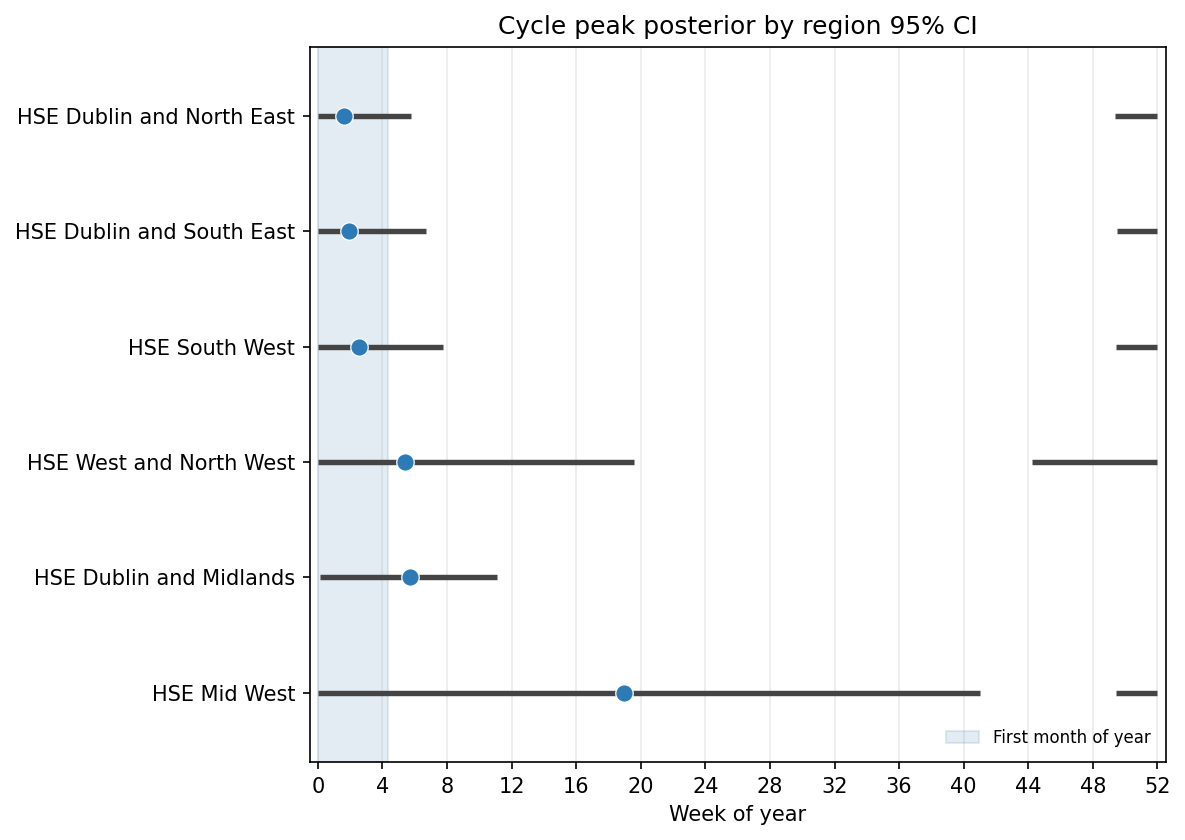

OK -> May_Presentation/tables/rendered/phase_wrap_v26.png


In [60]:
# Region order: most NY-aligned at the top, diffuse at the bottom (matches table sort)
ordered = sorted(regions,
                 key=lambda r: np.mean(circular_distance(phases[r], NY_WEEK) <= WEEKS_PER_MONTH),
                 reverse=True)

fig, ax = plt.subplots(figsize=(8, 0.7 * len(ordered) + 1.5), dpi=150)

ax.axvspan(0, WEEKS_PER_MONTH, alpha=0.15, color='steelblue',
           label='First month of year')

y_pos = np.arange(len(ordered))[::-1]  # top region first

for y, region in zip(y_pos, ordered):
    p = phases[region]
    lo, hi = circular_hpd(p)
    width  = arc_width(lo, hi)
    mean_w = circular_mean(p)


    if lo <= hi:
        ax.hlines(y, lo, hi, color='#444', linewidth=2.6, zorder=2)
    else:
        # Wrap: two segments
        ax.hlines(y, lo, PERIOD, color='#444', linewidth=2.6, zorder=2)
        ax.hlines(y, 0, hi, color='#444', linewidth=2.6, zorder=2)

    ax.scatter([mean_w], [y], s=70, zorder=3,
               color='#2c7bb6', edgecolors='white', linewidth=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(ordered)
ax.set_xticks(np.arange(0, PERIOD + 1, 4))
ax.set_xlabel('Week of year')
ax.set_xlim(-0.5, PERIOD + 0.5)
ax.set_ylim(-0.6, len(ordered) - 0.4)
ax.set_title('Cycle peak posterior by region 95% CI')
ax.legend(loc='lower right', fontsize=8, frameon=False)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
render_plot(f'phase_wrap_{FULL_VERSION.replace(".", "")}', fig)

## Pairwise phase comparison

$$d_{ij} = \min\!\bigl(|\theta_i - \theta_j|_{52},\ 52 - |\theta_i - \theta_j|_{52}\bigr)$$

For each pair of regions, the **circular distance** between their cycle peaks per posterior sample gives a distribution of "how far apart" their peaks are. Distance is bounded $[0, 26]$ weeks (a half-cycle).

Reported per pair:

- **Mean diff (wk)** — average circular distance in weeks
- **95% CI** — equal-tailed credible interval on the distance (works here because the distance is non-circular, bounded in $[0, 26]$)
- **P(>1mo apart)** — posterior probability that their peaks differ by more than 1 month

Pairs with **P(>1mo apart) close to 1** are decisively out of sync.

                                            Comparison  Mean diff (wk)      95% CI Contains 0
             HSE Dublin and North East vs HSE Mid West       15.380940 [1.4, 25.5]         No
             HSE Dublin and South East vs HSE Mid West       15.201375 [1.4, 25.4]         No
                        HSE Mid West vs HSE South West       14.873453 [1.2, 25.4]         No
               HSE Mid West vs HSE West and North West       13.251579 [0.8, 25.3]         No
               HSE Dublin and Midlands vs HSE Mid West       13.134078 [0.9, 25.1]         No
  HSE Dublin and North East vs HSE West and North West        6.056198 [0.2, 19.2]         No
  HSE Dublin and South East vs HSE West and North West        5.970183 [0.2, 19.1]         No
             HSE South West vs HSE West and North West        5.830791 [0.2, 18.9]         No
    HSE Dublin and Midlands vs HSE West and North West        5.371301 [0.2, 18.3]         No
  HSE Dublin and Midlands vs HSE Dublin and North East      

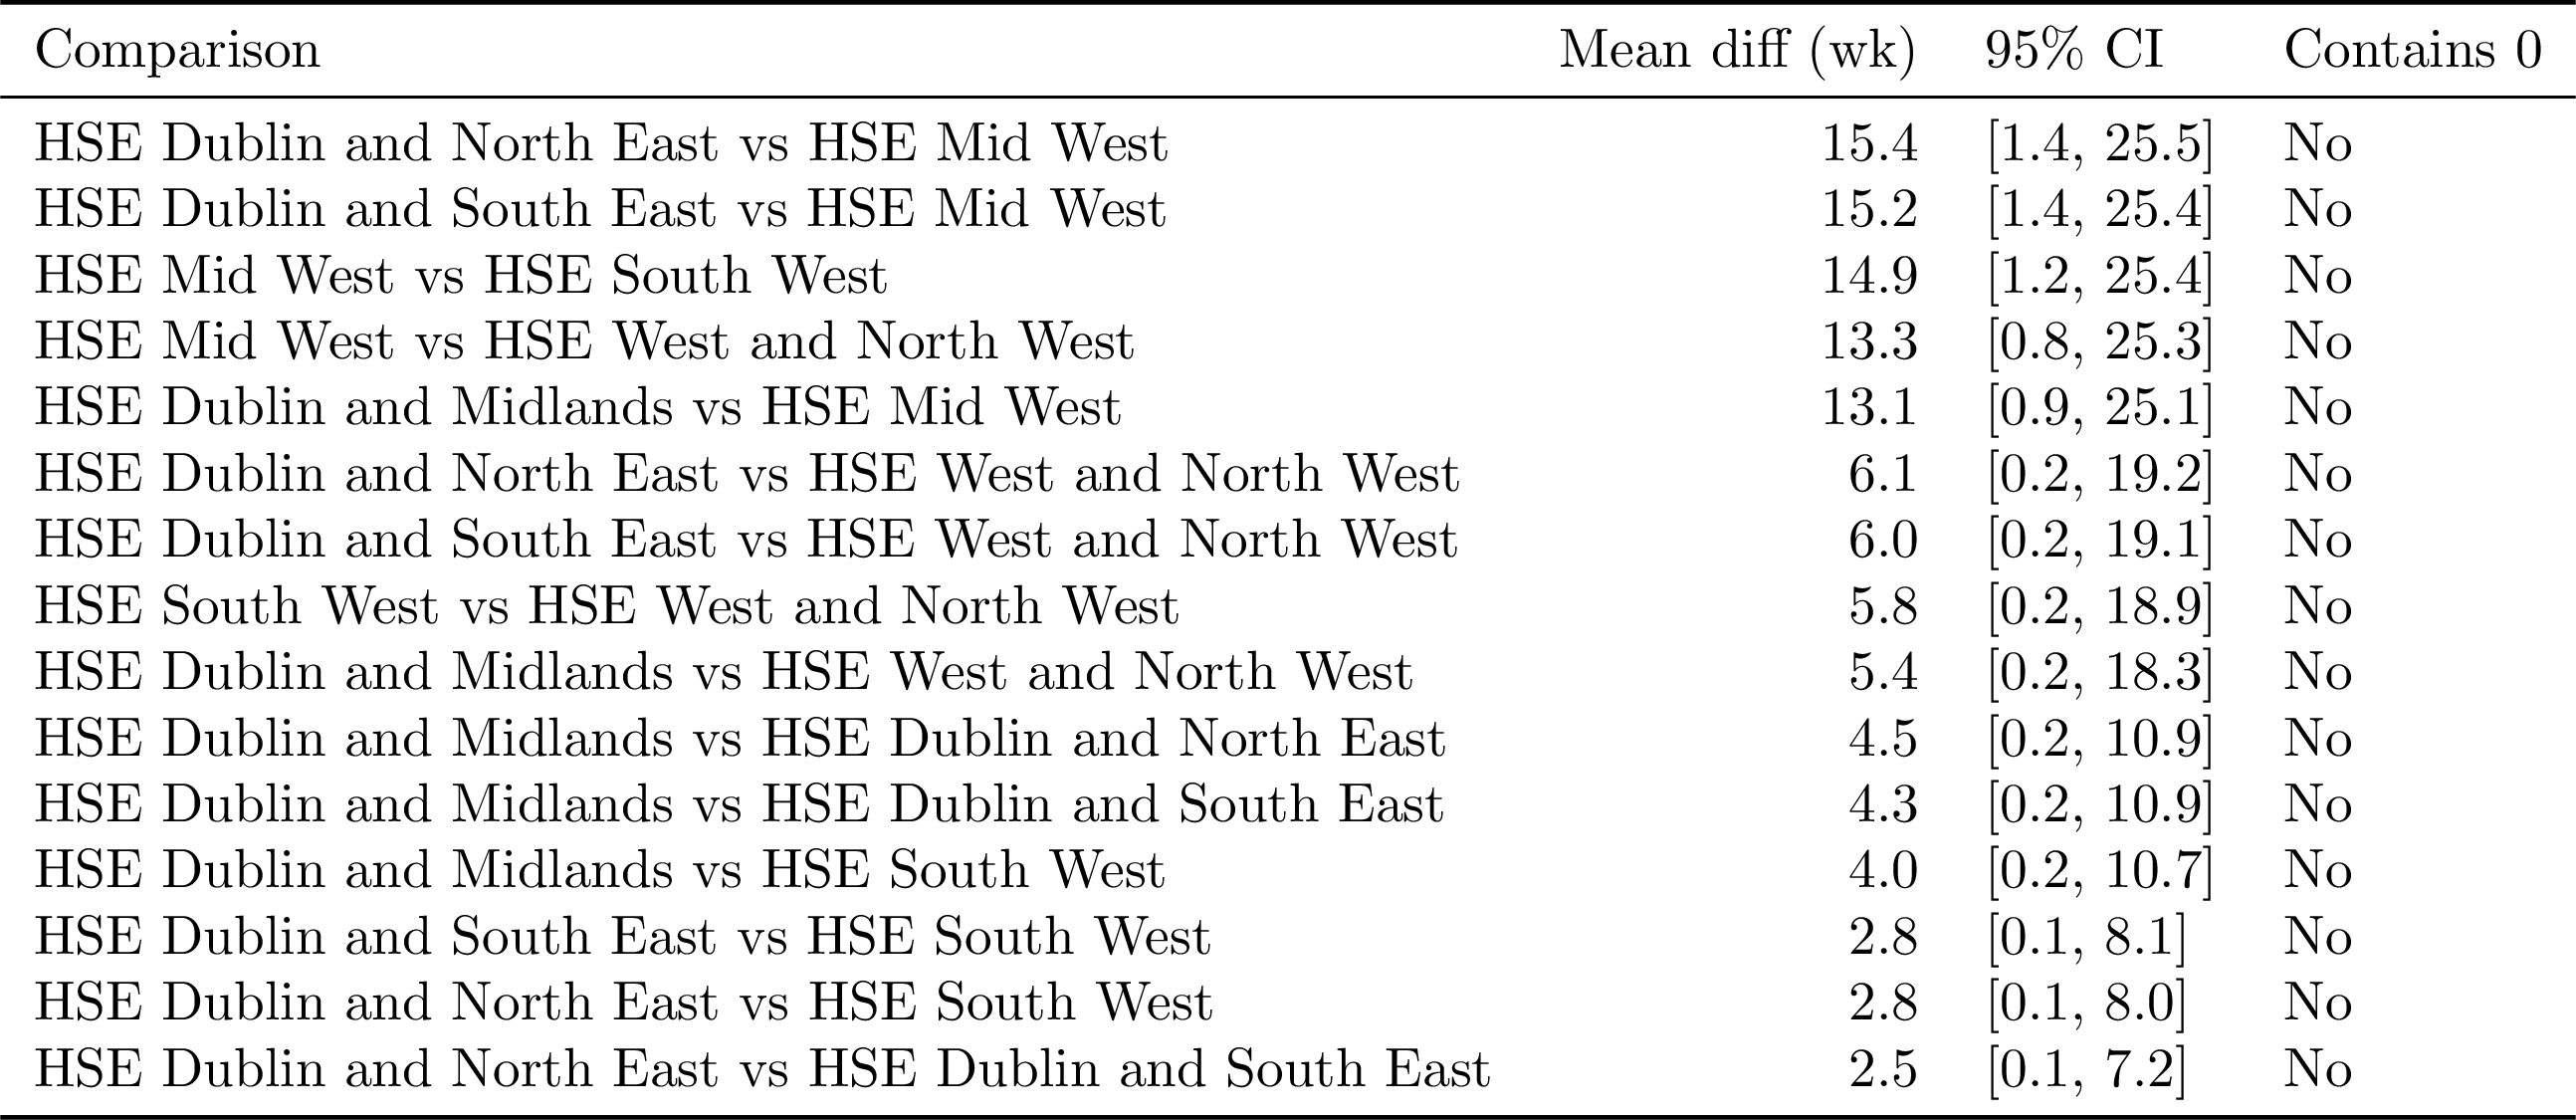

OK -> May_Presentation/tables/rendered/phase_pairwise_v26.png


In [48]:
from itertools import combinations

pair_rows = []
for i, j in combinations(range(len(regions)), 2):
    r_i, r_j = regions[i], regions[j]
    d = circular_distance(phases[r_i], phases[r_j])  # samples × 1, in [0, 26]
    lo, hi = np.quantile(d, [0.025, 0.975])
    pair_rows.append({
        'Comparison':     f"{r_i} vs {r_j}",
        'Mean diff (wk)': d.mean(),
        '95% CI':         f"[{lo:.1f}, {hi:.1f}]",
        'Contains 0':     'Yes' if lo <= 0 <= hi else 'No',
    })

pair_df = (pd.DataFrame(pair_rows)
           .sort_values('Mean diff (wk)', ascending=False)
           .reset_index(drop=True))
print(pair_df.to_string(index=False))

pair_df = escape_df(pair_df)

body = (pair_df.style
        .format({'Mean diff (wk)': '{:.1f}', 'P(>1mo apart)': '{:.3f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='lrll'))

render_table(f'phase_pairwise_{FULL_VERSION.replace(".", "")}', body)

## Global amplitude posterior

$$A_i = \sqrt{\beta_i^2 + \gamma_i^2}$$

Per-region posterior summary of the cycle amplitude — the size of the annual swing in trolley counts (in scaled units, per 10k pop) attributable to the cycle. Regions are sorted by posterior mean amplitude, descending.

                   Region     Mean       95% CI Contains 0
           HSE South West 1.163024 [0.54, 1.81]         No
  HSE Dublin and Midlands 0.857061 [0.39, 1.35]         No
HSE Dublin and South East 0.771106 [0.39, 1.17]         No
  HSE West and North West 0.708266 [0.15, 1.38]         No
HSE Dublin and North East 0.707446 [0.38, 1.05]         No
             HSE Mid West 0.626437 [0.12, 1.34]         No


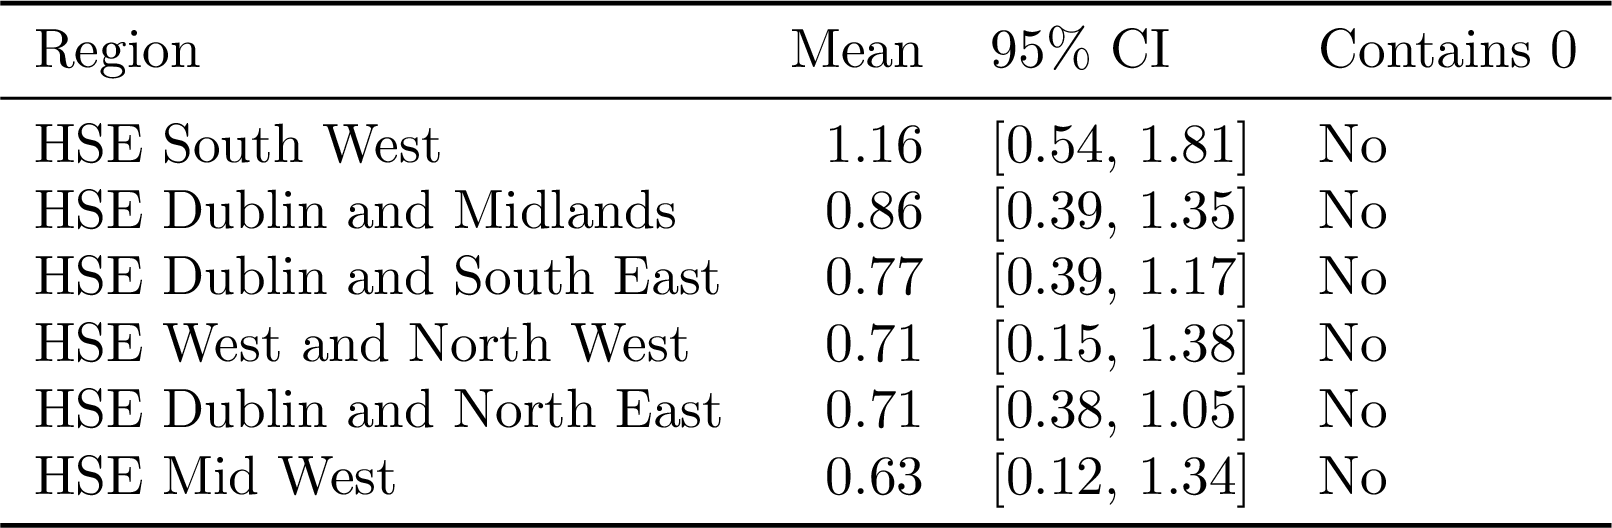

OK -> May_Presentation/tables/rendered/amplitude_global_v26.png


In [49]:
from pyjags_pipeline.significance import compute_amplitude

ampl = compute_amplitude(raw, regions)  # dict region -> Series of posterior amplitudes

amp_rows = []
for region in regions:
    a = ampl[region].values
    lo, hi = np.quantile(a, [0.025, 0.975])
    amp_rows.append({
        'Region':  region,
        'Mean':    a.mean(),
        '95% CI':  f"[{lo:.2f}, {hi:.2f}]",
        'Contains 0': 'Yes' if lo <= 0 <= hi else 'No',
    })

amp_df = (pd.DataFrame(amp_rows)
          .sort_values('Mean', ascending=False)
          .reset_index(drop=True))
print(amp_df.to_string(index=False))

amp_df = escape_df(amp_df)

body = (amp_df.style
        .format({'Mean': '{:.2f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='lrll'))

render_table(f'amplitude_global_{FULL_VERSION.replace(".", "")}', body)

## Pairwise amplitude comparison

$$\Delta A_{ij} = A_i - A_j$$

For each pair of regions, the difference of their cycle amplitudes per posterior sample. Regions are ordered so the mean difference is positive.

Reported per pair:

- **Mean diff** — posterior mean of $A_i - A_j$ (in scaled units, per 10k pop)
- **95% CI** — equal-tailed credible interval on the difference
- **P(>)** — posterior probability that $A_i > A_j$

Pairs with **P(>) close to 1** have decisively different cycle sizes.

               Comparison                        vs  Mean diff        95% CI Contains 0
           HSE South West              HSE Mid West   0.536587 [-0.40, 1.38]        Yes
           HSE South West HSE Dublin and North East   0.455579 [-0.25, 1.18]        Yes
           HSE South West   HSE West and North West   0.454758 [-0.46, 1.32]        Yes
           HSE South West HSE Dublin and South East   0.391918 [-0.35, 1.14]        Yes
           HSE South West   HSE Dublin and Midlands   0.305963 [-0.49, 1.11]        Yes
  HSE Dublin and Midlands              HSE Mid West   0.230624 [-0.62, 0.96]        Yes
  HSE Dublin and Midlands HSE Dublin and North East   0.149616 [-0.43, 0.74]        Yes
  HSE Dublin and Midlands   HSE West and North West   0.148795 [-0.67, 0.90]        Yes
HSE Dublin and South East              HSE Mid West   0.144669 [-0.65, 0.81]        Yes
  HSE Dublin and Midlands HSE Dublin and South East   0.085955 [-0.52, 0.71]        Yes
  HSE West and North West       

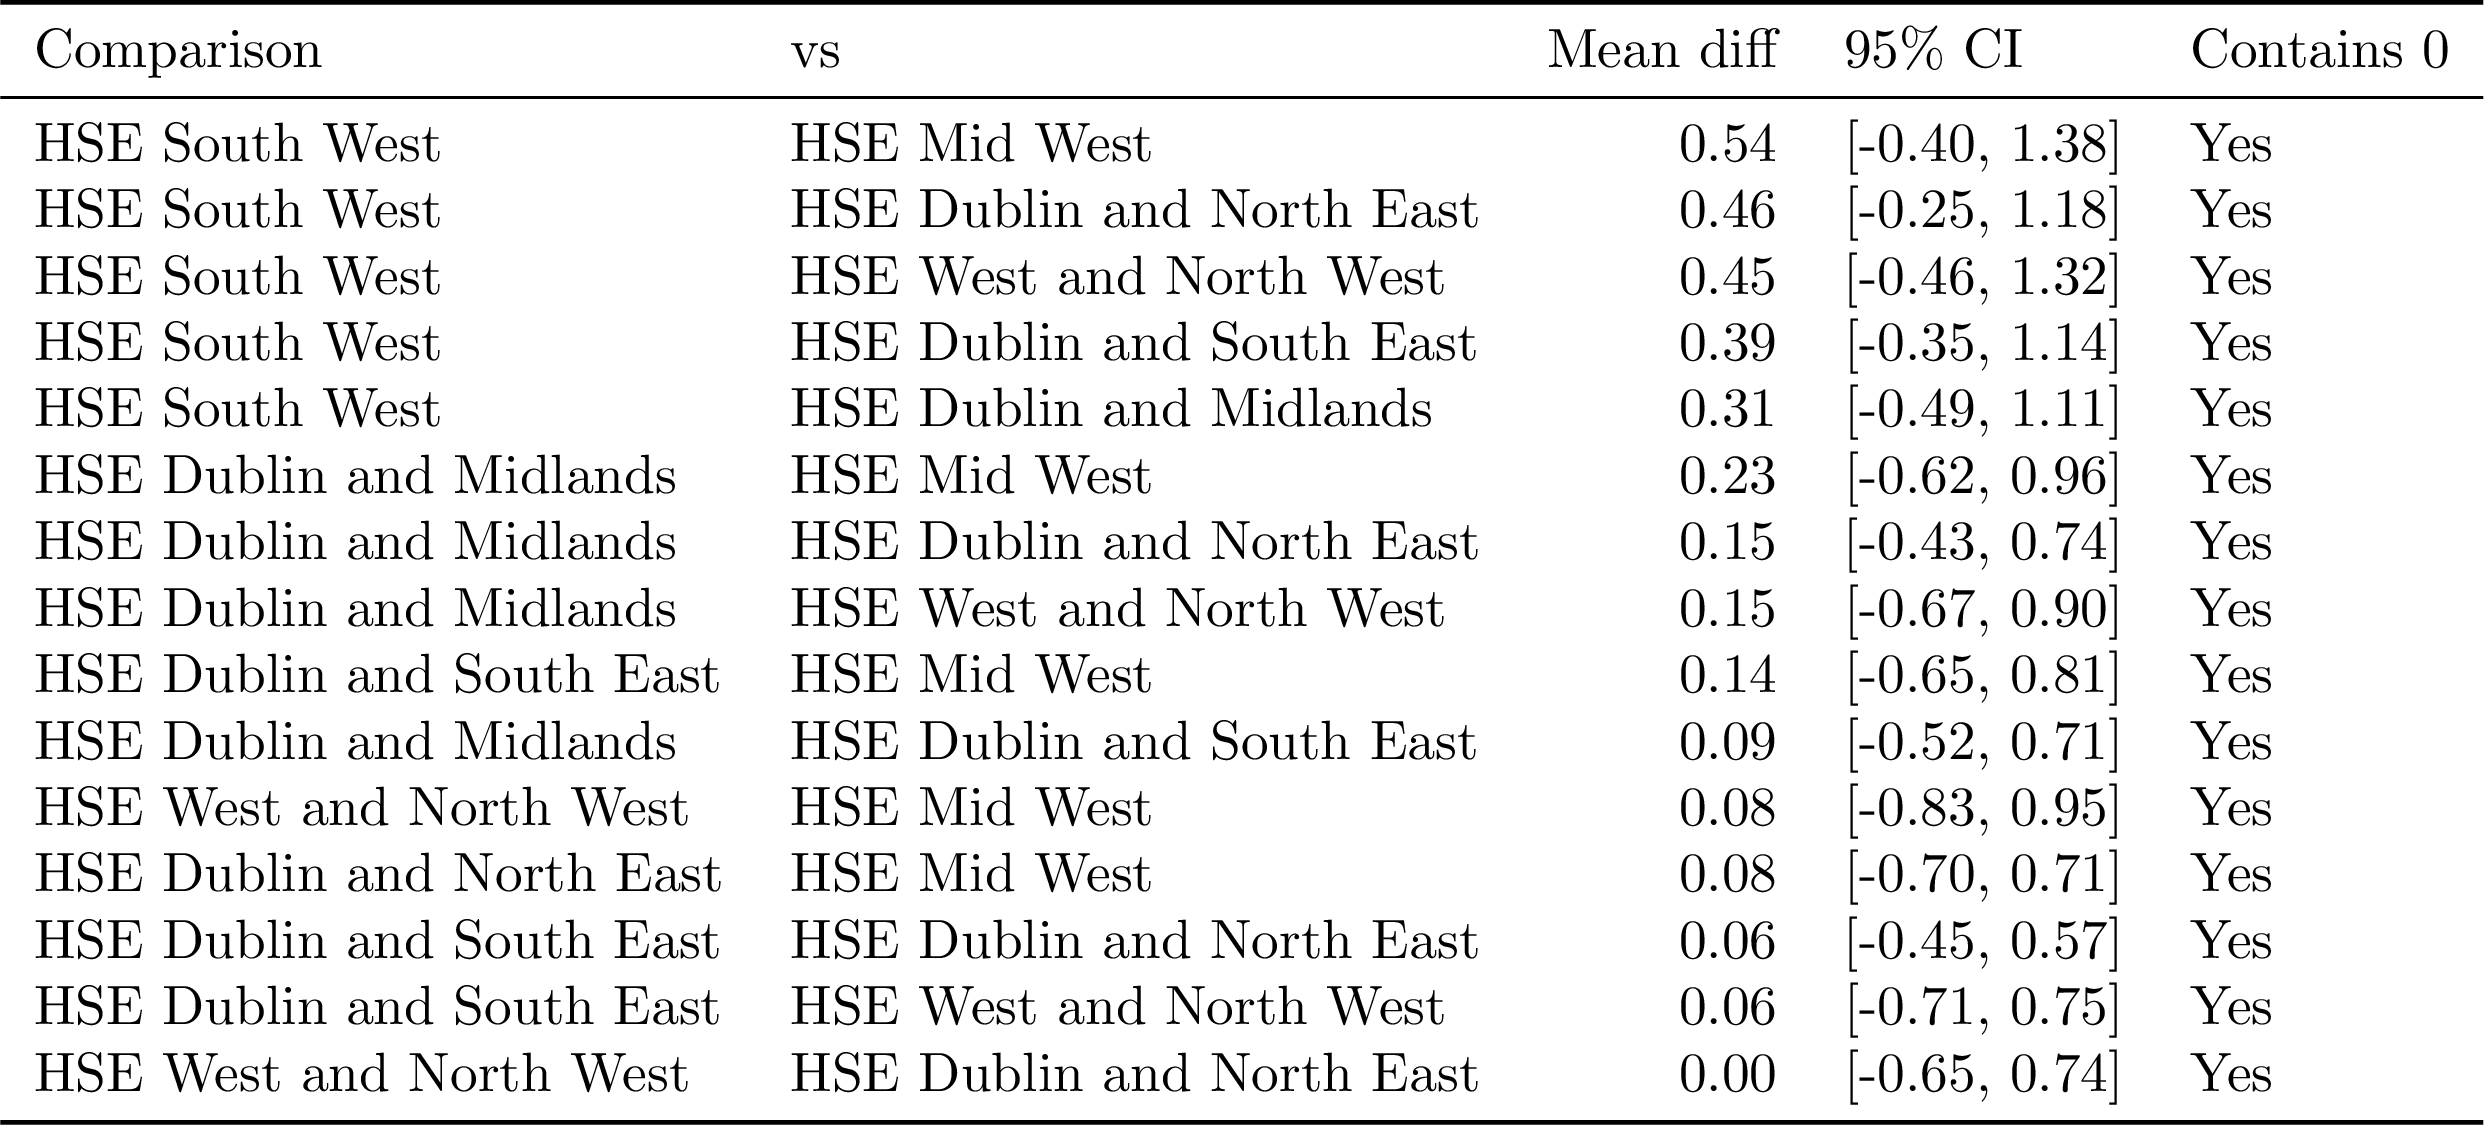

OK -> May_Presentation/tables/rendered/amplitude_pairwise_v26.png


In [50]:
amp_pair_rows = []
for i, j in combinations(range(len(regions)), 2):
    a_i = ampl[regions[i]].values
    a_j = ampl[regions[j]].values
    diff = a_i - a_j
    r_i, r_j = regions[i], regions[j]
    if diff.mean() < 0:
        r_i, r_j = r_j, r_i
        diff = -diff
    lo, hi = np.quantile(diff, [0.025, 0.975])
    amp_pair_rows.append({
        'Comparison':  f"{r_i}",
        'vs':  f"{r_j}",
        'Mean diff':   diff.mean(),
        '95% CI':      f"[{lo:.2f}, {hi:.2f}]",
        'Contains 0': 'Yes' if lo <= 0 <= hi else 'No',
    })

amp_pair_df = (pd.DataFrame(amp_pair_rows)
               .sort_values('Mean diff', ascending=False)
               .reset_index(drop=True))
print(amp_pair_df.to_string(index=False))

amp_pair_df = escape_df(amp_pair_df)

body = (amp_pair_df.style
        .format({'Mean diff': '{:.2f}', '95% CI': '{:.2f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrll'))

render_table(f'amplitude_pairwise_{FULL_VERSION.replace(".", "")}', body)

## Global baseline posterior

Per-region posterior summary of the baseline level $\alpha_i$ — the average weekly trolley count per 10k population each region drifts around when the cycle, NY effect, and MW reset are all zero. Regions are sorted by posterior mean baseline, descending.

- **Mean** — posterior mean of $\alpha_i$
- **95% CI** — equal-tailed credible interval
- **Contains 0** — whether the CI straddles zero (a baseline indistinguishable from 0 is a sanity check; in practice all regions sit clearly above 0)

                   Region     Mean       95% CI Contains 0
             HSE Mid West 8.165877 [7.54, 8.79]         No
  HSE West and North West 6.466896 [5.93, 7.01]         No
           HSE South West 4.536174 [4.06, 5.02]         No
  HSE Dublin and Midlands 3.868047 [3.50, 4.24]         No
HSE Dublin and South East 2.999153 [2.71, 3.29]         No
HSE Dublin and North East 2.226785 [1.98, 2.48]         No


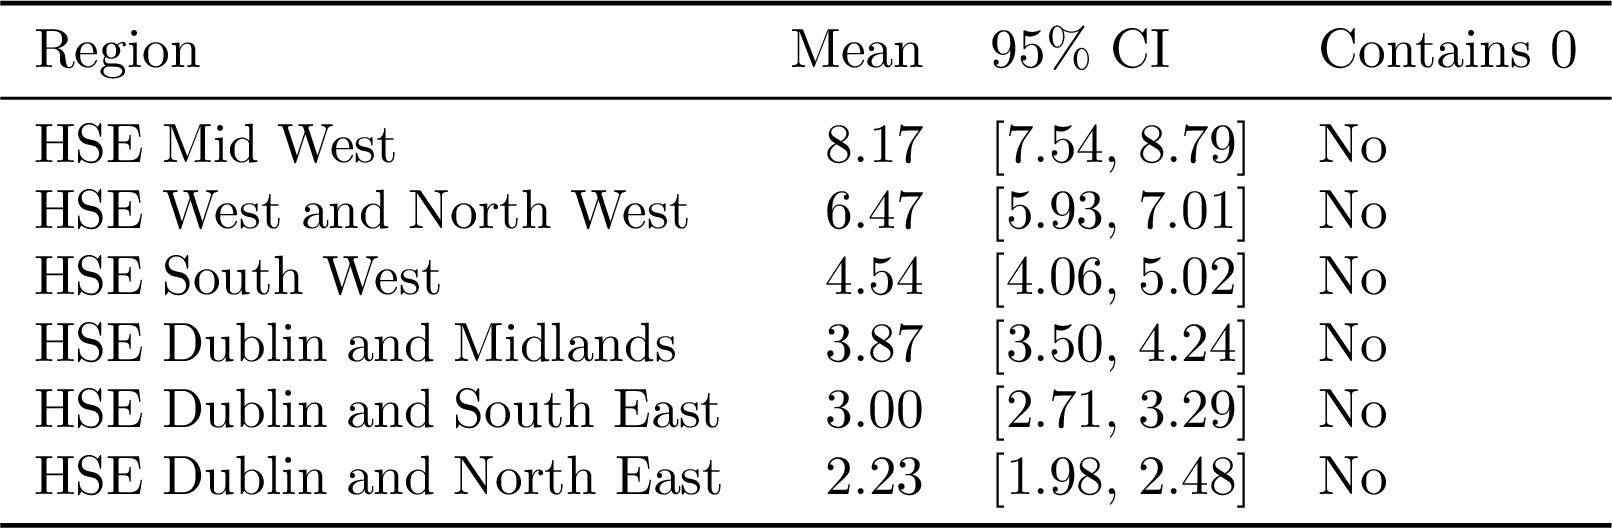

OK -> May_Presentation/tables/rendered/alpha_global_v26.png


In [51]:
alpha_rows = []
for i, region in enumerate(regions):
    a = raw[f'alpha[{i+1}]'].values
    lo, hi = np.quantile(a, [0.025, 0.975])
    alpha_rows.append({
        'Region':     region,
        'Mean':       a.mean(),
        '95% CI':     f"[{lo:.2f}, {hi:.2f}]",
        'Contains 0': 'Yes' if lo <= 0 <= hi else 'No',
    })

alpha_df = (pd.DataFrame(alpha_rows)
            .sort_values('Mean', ascending=False)
            .reset_index(drop=True))
print(alpha_df.to_string(index=False))

body = (escape_df(alpha_df).style
        .format({'Mean': '{:.2f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='lrll'))

render_table(f'alpha_global_{FULL_VERSION.replace(".", "")}', body)

## Baseline map by HSE region

Choropleth of posterior mean $\alpha_i$ on Ireland's six HSE health-region polygons (same `hse_regions.geojson` the live dashboard uses). Reproduces the dashboard's per-10k visualisation but anchored on the **model-estimated** baseline rather than a single day's count.

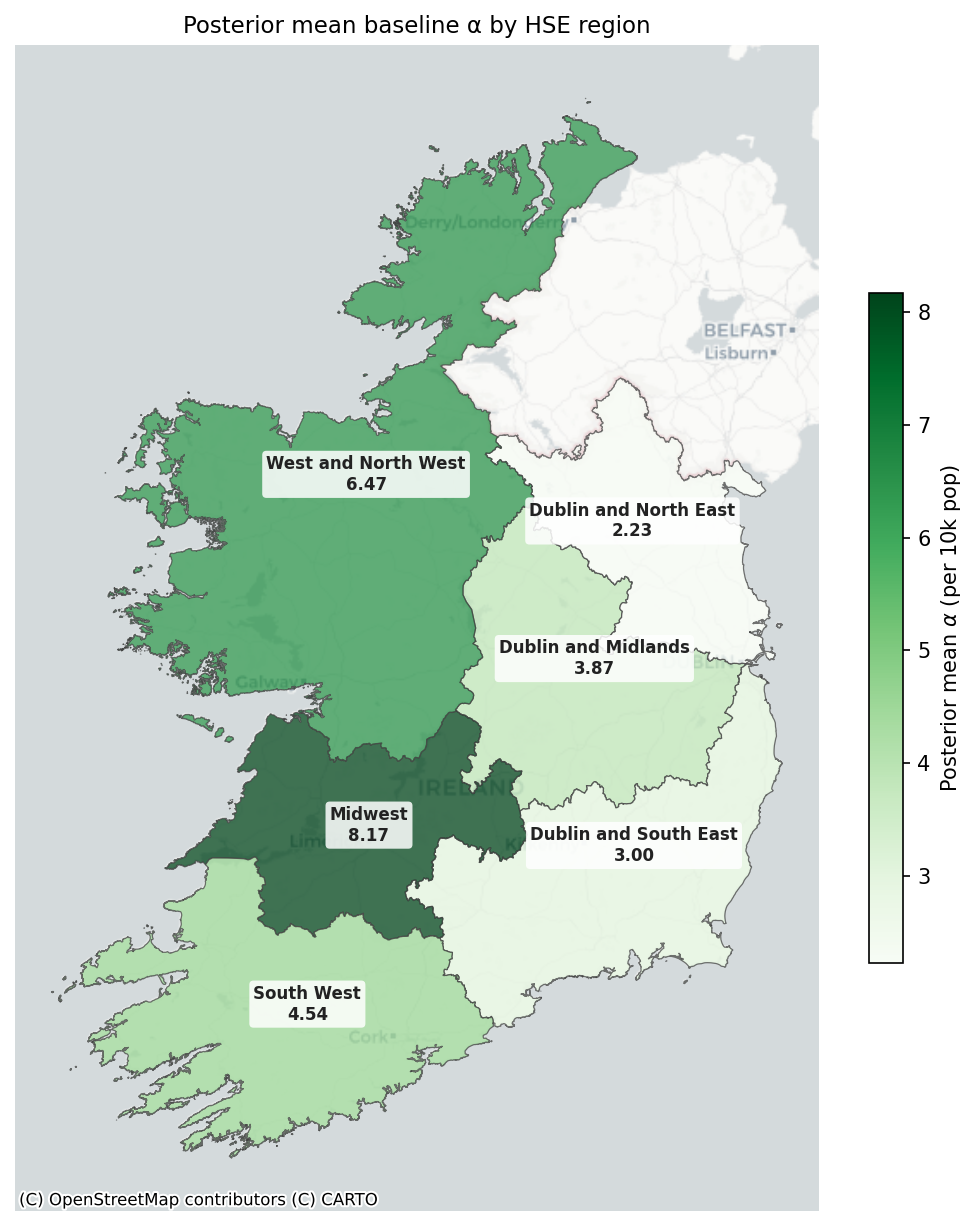

OK -> May_Presentation/tables/rendered/alpha_map_v26.png


In [52]:
import geopandas as gpd
import contextily as cx

NAME_MAP = {
    'HSE Dublin and Midlands':   'HSE Dublin and Midlands HR',
    'HSE Dublin and North East': 'HSE Dublin and North East HR',
    'HSE Dublin and South East': 'HSE Dublin and South East HR',
    'HSE Mid West':              'HSE Midwest HR',
    'HSE South West':            'HSE South West HR',
    'HSE West and North West':   'HSE West and North West HR',
}

# Manual nudge per region in metres (EPSG:3857 Web Mercator).
# Negative dx -> west,  Negative dy -> south.
# Edit values to reposition labels; leave at (0, 0) for auto.
LABEL_OFFSETS = {
    'HSE Dublin and Midlands HR':   (0,       0),
    'HSE Dublin and North East HR': (0,       0),
    'HSE Dublin and South East HR': (0,       0),
    'HSE Midwest HR':               (0,       0),
    'HSE South West HR':            (0,       0),
    'HSE West and North West HR':   (-20000, -25000),
}

geo_path = PROJECT_ROOT / 'dashboard' / 'hse_regions.geojson'
gdf = gpd.read_file(geo_path).to_crs(epsg=3857)  # Web Mercator for contextily basemap

alpha_means = {region: float(raw[f'alpha[{i+1}]'].mean())
               for i, region in enumerate(regions)}
gdf['alpha_mean'] = gdf['HR_operational_name'].map(
    {NAME_MAP[r]: v for r, v in alpha_means.items()}
)

fig, ax = plt.subplots(figsize=(7, 8.5), dpi=150)
gdf.plot(
    column='alpha_mean',
    cmap='Greens',
    linewidth=0.6,
    edgecolor='#444',
    alpha=0.75,
    legend=True,
    legend_kwds={
        'label': r'Posterior mean $\alpha$ (per 10k pop)',
        'shrink': 0.55,
        'orientation': 'vertical',
    },
    ax=ax,
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf.crs, zoom=7)

# Region label + value at each polygon's representative point + manual nudge
for _, row in gdf.iterrows():
    pt = row.geometry.representative_point()
    dx, dy = LABEL_OFFSETS.get(row['HR_operational_name'], (0, 0))
    short = row['HR_operational_name'].replace(' HR', '').replace('HSE ', '')
    ax.annotate(
        f"{short}\n{row['alpha_mean']:.2f}",
        xy=(pt.x + dx, pt.y + dy),
        ha='center', va='center',
        fontsize=8, color='#222', weight='bold',
        bbox=dict(boxstyle='round,pad=0.25',
                  facecolor='white', edgecolor='none', alpha=0.85),
    )

ax.set_axis_off()
ax.set_title('Posterior mean baseline α by HSE region', fontsize=11)
fig.tight_layout()
render_plot(f'alpha_map_{FULL_VERSION.replace(".", "")}', fig)

## Pairwise baseline comparison

$$\Delta\alpha_{ij} = \alpha_i - \alpha_j$$

For each pair of regions, the difference of their baseline levels $\alpha$ per posterior sample. Pairs are oriented so the mean difference is positive.

Reported per pair:

- **Mean diff** — posterior mean of $\alpha_i - \alpha_j$ (in scaled units, per 10k pop)
- **95% CI** — equal-tailed credible interval on the difference
- **Contains 0** — whether the 95% CI straddles zero

Pairs whose 95% CI excludes 0 have **decisively different baselines**.

               Comparison                        vs  Mean diff       95% CI Contains 0
             HSE Mid West HSE Dublin and North East   5.939092 [5.26, 6.61]         No
             HSE Mid West HSE Dublin and South East   5.166724 [4.48, 5.85]         No
             HSE Mid West   HSE Dublin and Midlands   4.297830 [3.57, 5.02]         No
  HSE West and North West HSE Dublin and North East   4.240111 [3.65, 4.83]         No
             HSE Mid West            HSE South West   3.629704 [2.84, 4.41]         No
  HSE West and North West HSE Dublin and South East   3.467743 [2.86, 4.08]         No
  HSE West and North West   HSE Dublin and Midlands   2.598849 [1.95, 3.25]         No
           HSE South West HSE Dublin and North East   2.309388 [1.77, 2.85]         No
  HSE West and North West            HSE South West   1.930723 [1.21, 2.65]         No
             HSE Mid West   HSE West and North West   1.698981 [0.87, 2.52]         No
  HSE Dublin and Midlands HSE Dublin and No

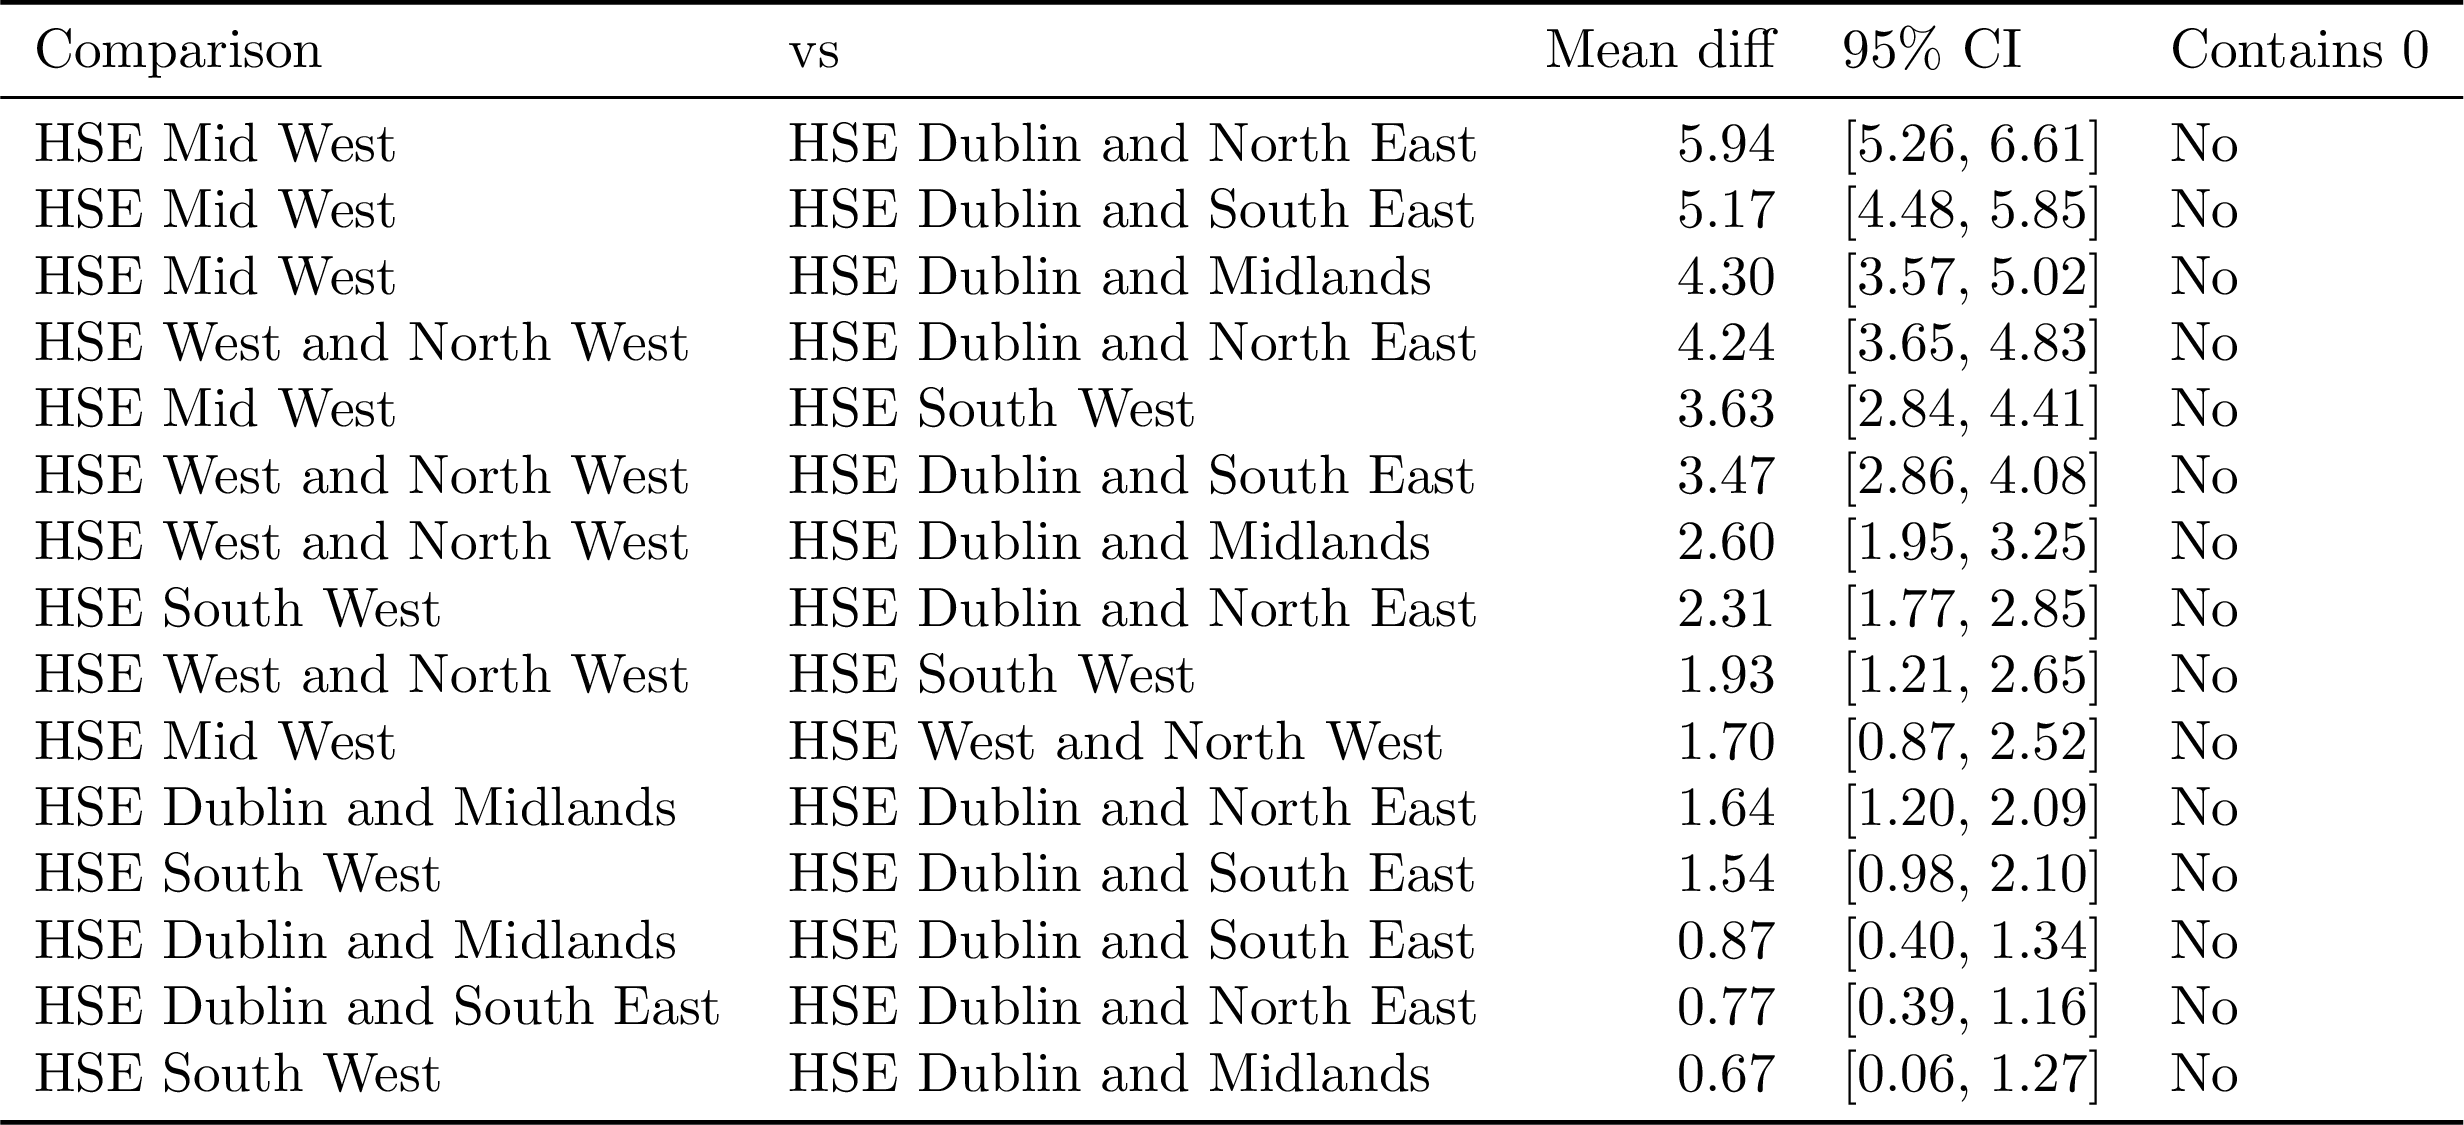

OK -> May_Presentation/tables/rendered/alpha_pairwise_v26.png


In [53]:
alpha_pair_rows = []
for i, j in combinations(range(len(regions)), 2):
    a_i = raw[f'alpha[{i+1}]'].values
    a_j = raw[f'alpha[{j+1}]'].values
    diff = a_i - a_j
    r_i, r_j = regions[i], regions[j]
    if diff.mean() < 0:
        r_i, r_j = r_j, r_i
        diff = -diff
    lo, hi = np.quantile(diff, [0.025, 0.975])
    alpha_pair_rows.append({
        'Comparison':  r_i,
        'vs':          r_j,
        'Mean diff':   diff.mean(),
        '95% CI':      f"[{lo:.2f}, {hi:.2f}]",
        'Contains 0':  'Yes' if lo <= 0 <= hi else 'No',
    })

alpha_pair_df = (pd.DataFrame(alpha_pair_rows)
                 .sort_values('Mean diff', ascending=False)
                 .reset_index(drop=True))
print(alpha_pair_df.to_string(index=False))

alpha_pair_df = escape_df(alpha_pair_df)

body = (alpha_pair_df.style
        .format({'Mean diff': '{:.2f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrll'))

render_table(f'alpha_pairwise_{FULL_VERSION.replace(".", "")}', body)

## Mid-West full reset effect

Pre/Mid/Post are panel weeks 85/86/87 (weeks ending 2024-08-11, -08-18, -08-25), covering the literature reset window 8 Aug – 19 Aug 2024 (refs 113, 114). Effect $\sigma_{\text{pre/mid/post}}$ is on the Mid-West only. 95% credible interval per period.

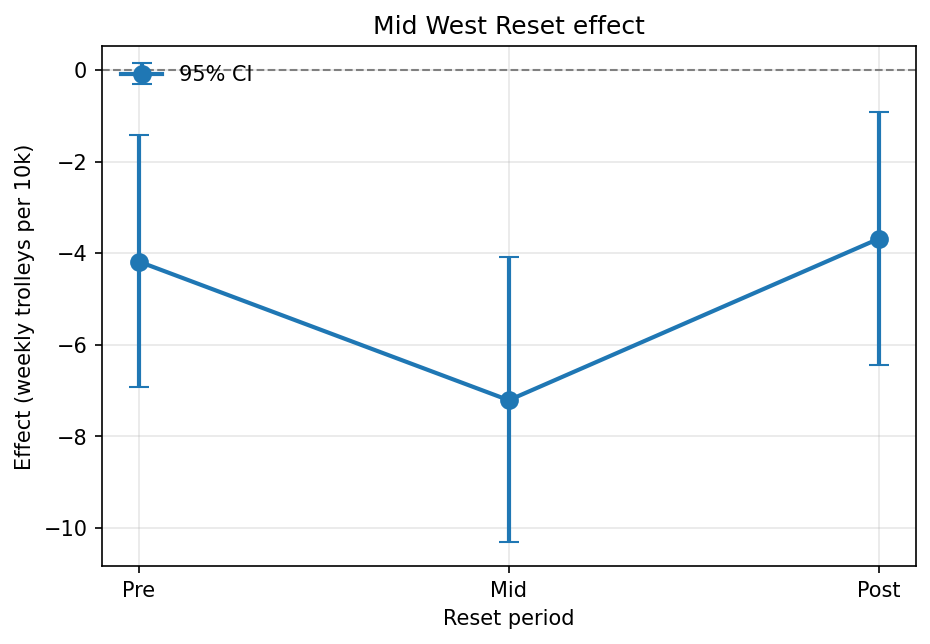

OK -> May_Presentation/tables/rendered/full_reset_v25.png
 Week      Mean          95% CI
   85 -4.183800  [-6.93, -1.43]
   86 -7.210557 [-10.32, -4.09]
   87 -3.685344  [-6.45, -0.92]


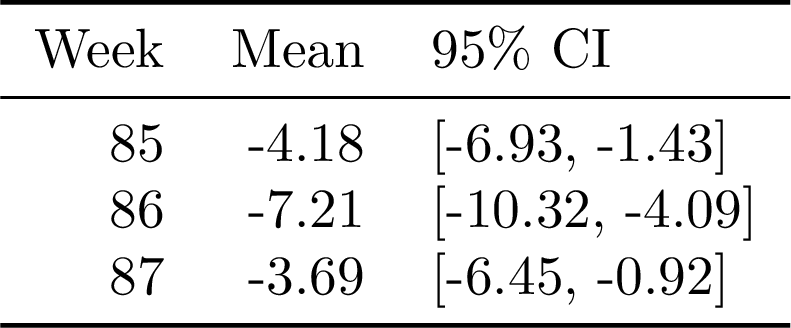

OK -> May_Presentation/tables/rendered/full_reset_v25_table.png


In [54]:
import numpy as np

raw_v25 = pd.read_csv(MODELS_DIR / 'v2.5' / 'raw_samples.csv')

PHASES = ['Pre', 'Mid', 'Post']
SIGMA_COLS = ['sigma_pre', 'sigma_mid', 'sigma_post']
WEEKS = [85, 86, 87]

LO_Q, HI_Q = 0.025, 0.975

means, lowers, uppers = [], [], []
for col in SIGMA_COLS:
    s = raw_v25[col].values
    means.append(s.mean())
    lo, hi = np.quantile(s, [LO_Q, HI_Q])
    lowers.append(lo)
    uppers.append(hi)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
yerr = [[m - l for m, l in zip(means, lowers)],
        [u - m for u, m in zip(uppers, means)]]
ax.errorbar(range(3), means, yerr=yerr, fmt='-o',
            capsize=5, linewidth=2, markersize=8,
            label='95% CI')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(range(3))
ax.set_xticklabels(PHASES)
ax.set_xlabel('Reset period')
ax.set_ylabel('Effect (weekly trolleys per 10k)')
ax.set_title('Mid West Reset effect')
ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.3)
render_plot('full_reset_v25', fig)

reset_df = pd.DataFrame({
    'Week':   WEEKS,
    'Mean':   means,
    '2.5%':   lowers,
    '97.5%':  uppers,
})
reset_df['95% CI'] = reset_df.apply(
    lambda r: f"[{r['2.5%']:.2f}, {r['97.5%']:.2f}]", axis=1)
display_reset = reset_df[['Week', 'Mean', '95% CI']]
print(display_reset.to_string(index=False))

body = (escape_df(display_reset).style
        .format({'Mean': '{:.2f}', 'Week': '{:d}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='rrl'))
render_table('full_reset_v25_table', body)

## Mid-West full reset effect (V2.6) — 3 reset weeks + 2 post weeks

Same shape as the V2.5 reset plot above, with 5 weekly indicators instead of 3. Aug 5 / Aug 12 / Aug 19 cover the literature reset window (8 Aug – 19 Aug 2024, refs 113-114); Aug 26 and Sep 2 are the **two added post-reset weeks**. Dotted red line marks the end of the literature reset window. 95% credible interval per week.

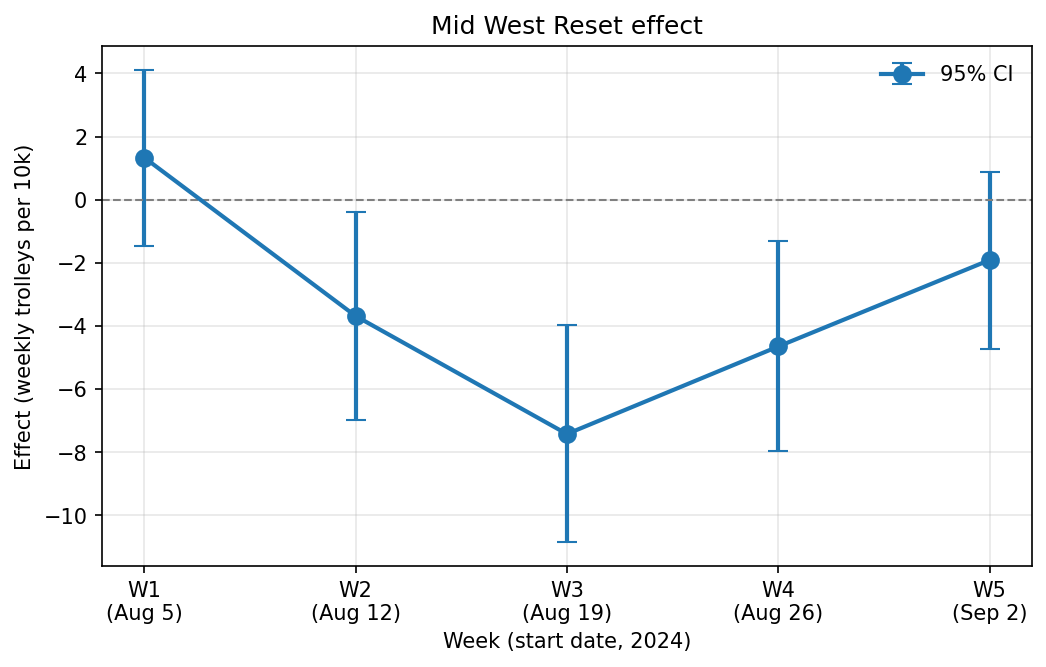

OK -> May_Presentation/tables/rendered/full_reset_v26.png
  Week Phase      Mean          95% CI
 Aug 5 Reset  1.334393   [-1.45, 4.11]
Aug 12 Reset -3.683771  [-6.98, -0.39]
Aug 19 Reset -7.422477 [-10.85, -3.97]
Aug 26  Post -4.649950  [-7.97, -1.32]
 Sep 2  Post -1.911404   [-4.72, 0.88]


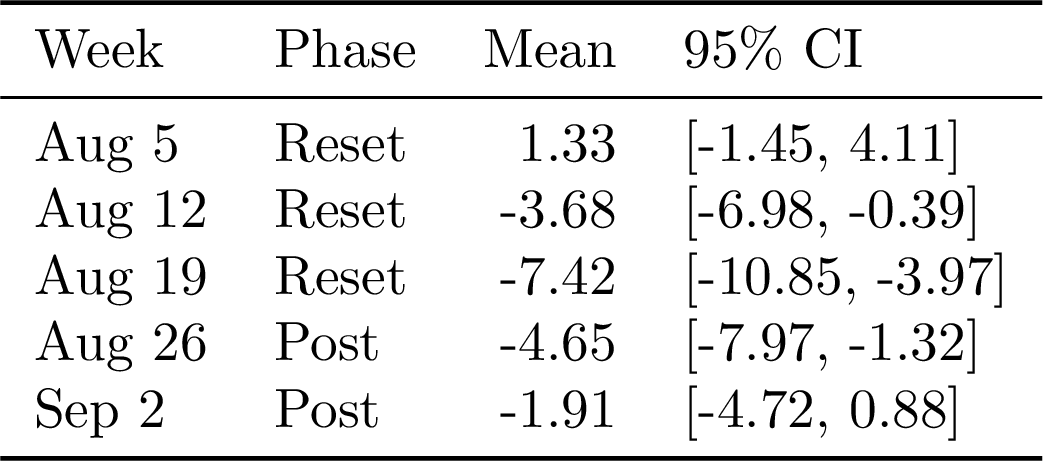

OK -> May_Presentation/tables/rendered/full_reset_v26_table.png


In [61]:
import numpy as np

raw_v26 = pd.read_csv(MODELS_DIR / 'v2.6' / 'raw_samples.csv')

LABELS = ['W1\n(Aug 5)', 'W2\n(Aug 12)', 'W3\n(Aug 19)',
          'W4\n(Aug 26)', 'W5\n(Sep 2)']
SIGMA_COLS = ['sigma_w1', 'sigma_w2', 'sigma_w3', 'sigma_w4', 'sigma_w5']

LO_Q, HI_Q = 0.025, 0.975

means, lowers, uppers = [], [], []
for col in SIGMA_COLS:
    s = raw_v26[col].values
    means.append(s.mean())
    lo, hi = np.quantile(s, [LO_Q, HI_Q])
    lowers.append(lo)
    uppers.append(hi)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
yerr = [[m - l for m, l in zip(means, lowers)],
        [u - m for u, m in zip(uppers, means)]]
ax.errorbar(range(5), means, yerr=yerr, fmt='-o',
            capsize=5, linewidth=2, markersize=8,
            label='95% CI')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(range(5))
ax.set_xticklabels(LABELS)
ax.set_xlabel('Week (start date, 2024)')
ax.set_ylabel('Effect (weekly trolleys per 10k)')
ax.set_title('Mid West Reset effect')
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.3)
render_plot('full_reset_v26', fig)

reset_df = pd.DataFrame({
    'Week':    ['Aug 5', 'Aug 12', 'Aug 19', 'Aug 26', 'Sep 2'],
    'Phase':   ['Reset', 'Reset', 'Reset', 'Post', 'Post'],
    'Mean':    means,
    '2.5%':    lowers,
    '97.5%':   uppers,
})
reset_df['95% CI'] = reset_df.apply(
    lambda r: f"[{r['2.5%']:.2f}, {r['97.5%']:.2f}]", axis=1)
display_reset = reset_df[['Week', 'Phase', 'Mean', '95% CI']]
print(display_reset.to_string(index=False))

body = (escape_df(display_reset).style
        .format({'Mean': '{:.2f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='llrl'))
render_table('full_reset_v26_table', body)

## Regional New Year effect

Per-region $\delta_{\text{pre}}$, $\delta_{\text{mid}}$, $\delta_{\text{post}}$ — regional NY deltas; the MW reset lives on the Aug 2024 `fr2` window so the deltas here are NY-specific. Pre = week-of-year 0 (NY), Mid = NY+1, Post = NY+2. 95% credible interval per period.

Tables are 3 rows in Pre / Mid / Post order — read alongside the plot above each.

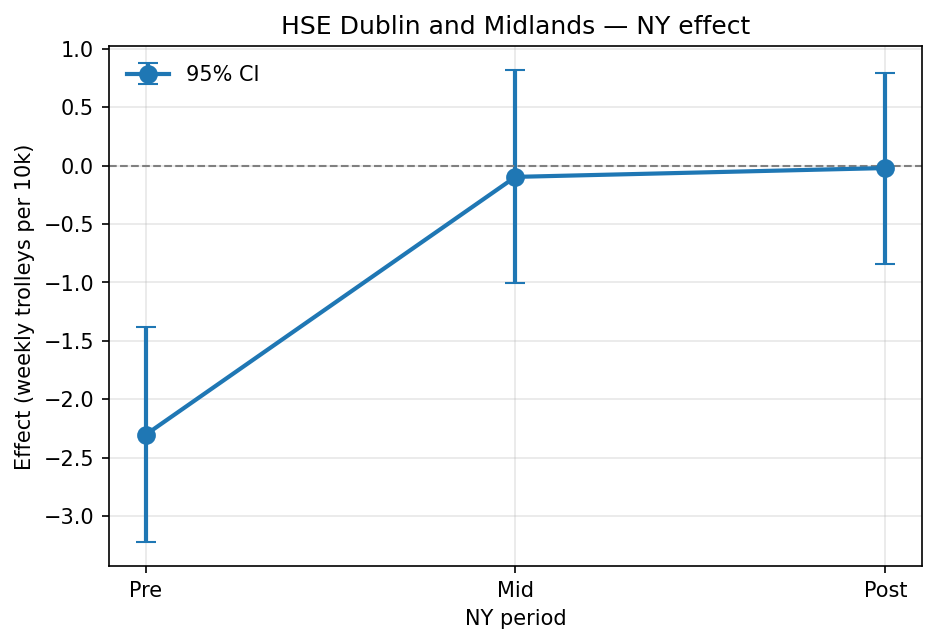

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_Midlands.png

=== HSE Dublin and Midlands ===
     Mean         95% CI
-2.304263 [-3.23, -1.38]
-0.095732  [-1.01, 0.82]
-0.020092  [-0.84, 0.80]


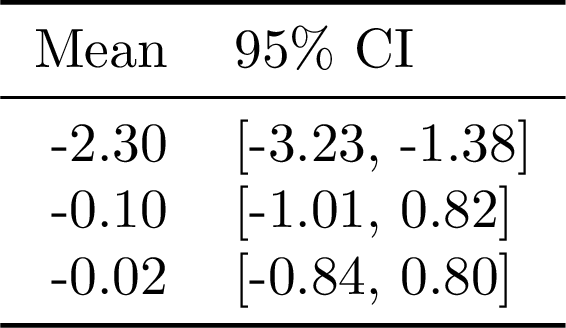

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_Midlands_table.png


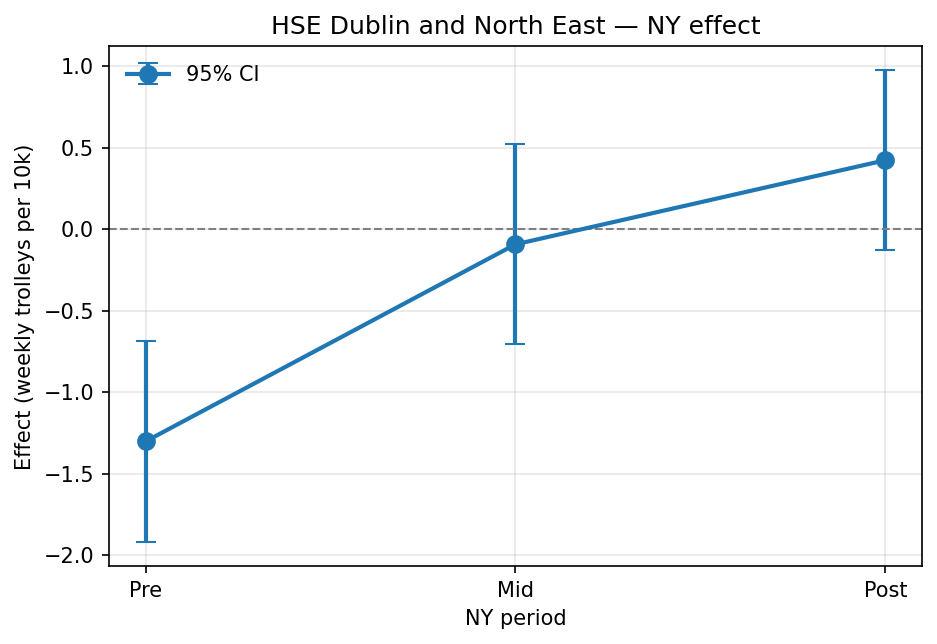

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_North_East.png

=== HSE Dublin and North East ===
     Mean         95% CI
-1.302635 [-1.92, -0.69]
-0.093475  [-0.71, 0.52]
 0.422630  [-0.13, 0.98]


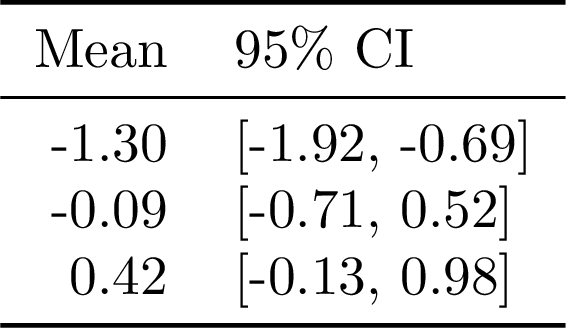

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_North_East_table.png


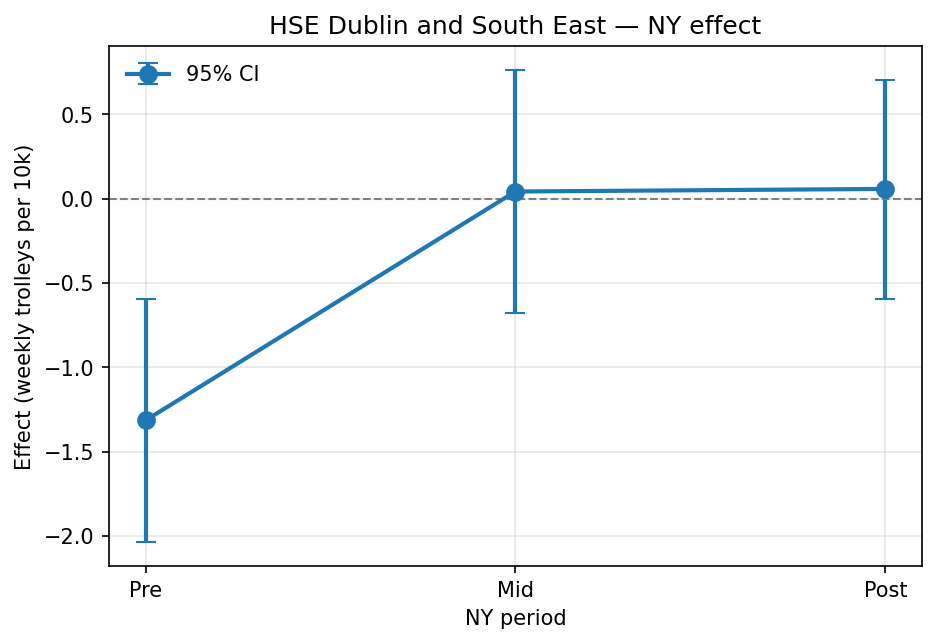

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_South_East.png

=== HSE Dublin and South East ===
     Mean         95% CI
-1.314104 [-2.04, -0.59]
 0.043233  [-0.67, 0.76]
 0.058590  [-0.59, 0.71]


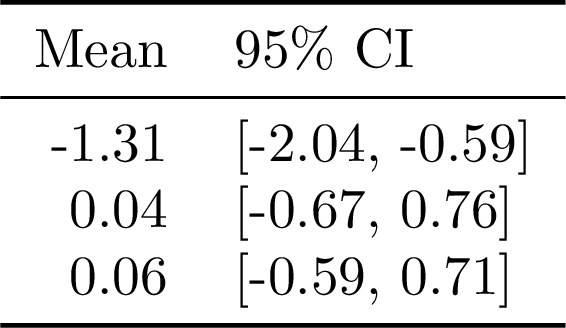

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Dublin_and_South_East_table.png


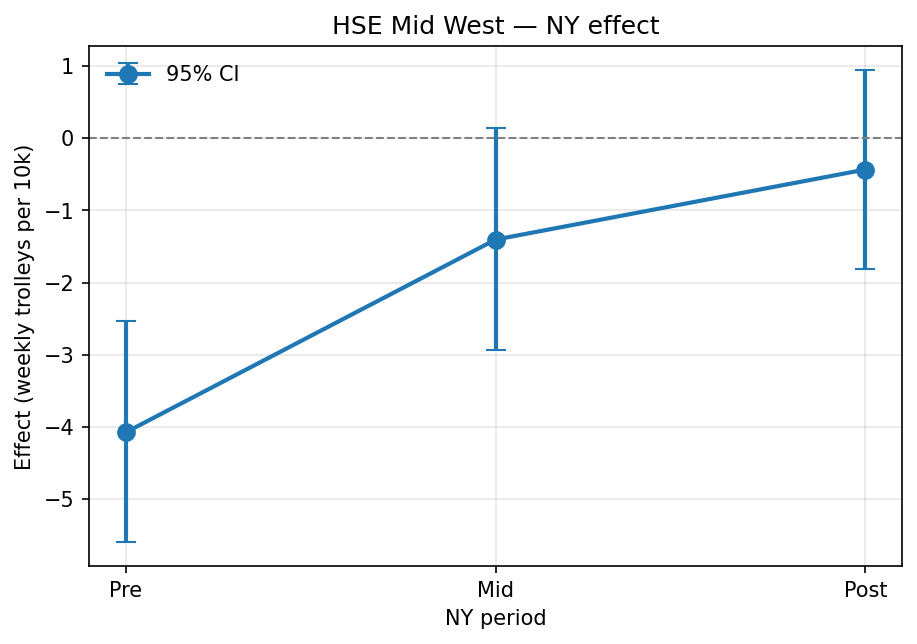

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Mid_West.png

=== HSE Mid West ===
     Mean         95% CI
-4.078569 [-5.60, -2.53]
-1.404644  [-2.94, 0.14]
-0.432634  [-1.82, 0.95]


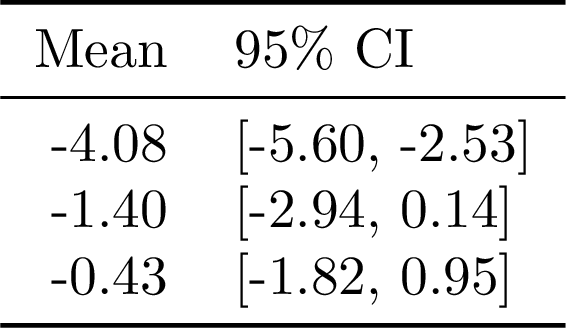

OK -> May_Presentation/tables/rendered/ny_v26_HSE_Mid_West_table.png


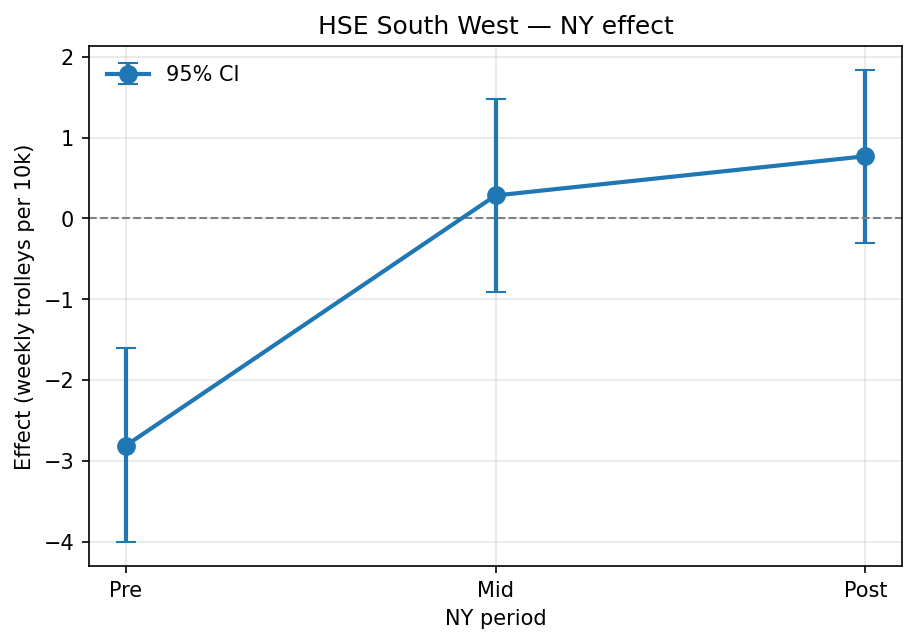

OK -> May_Presentation/tables/rendered/ny_v26_HSE_South_West.png

=== HSE South West ===
     Mean         95% CI
-2.810204 [-4.01, -1.60]
 0.284181  [-0.91, 1.48]
 0.769399  [-0.30, 1.84]


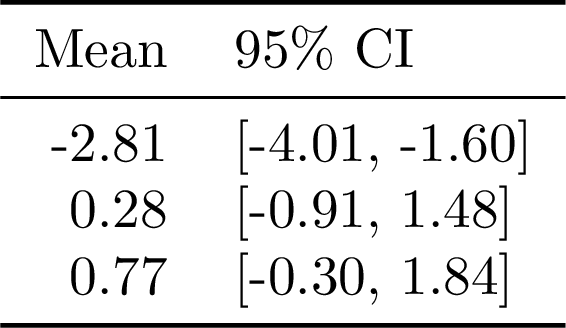

OK -> May_Presentation/tables/rendered/ny_v26_HSE_South_West_table.png


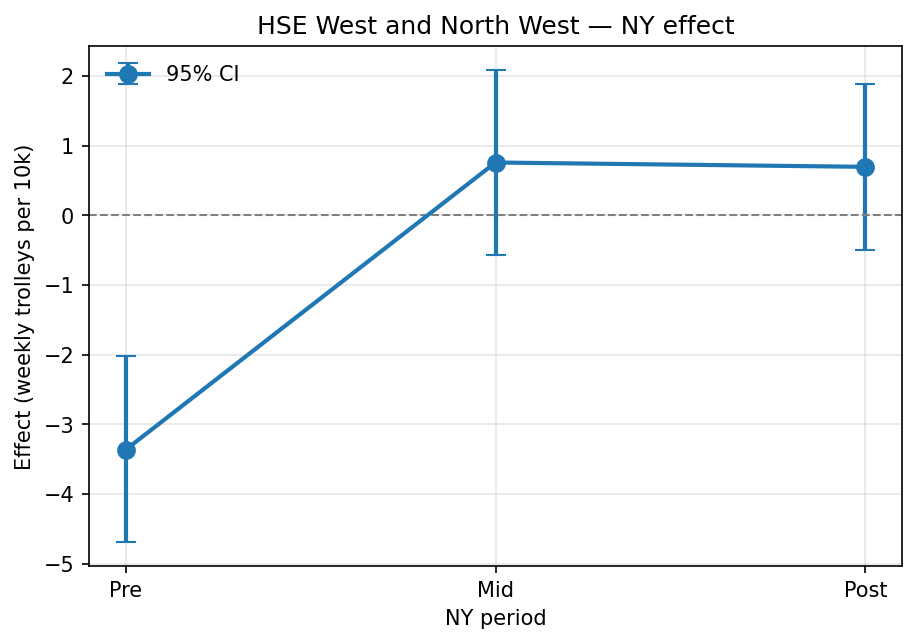

OK -> May_Presentation/tables/rendered/ny_v26_HSE_West_and_North_West.png

=== HSE West and North West ===
     Mean         95% CI
-3.363830 [-4.70, -2.02]
 0.760538  [-0.57, 2.09]
 0.698264  [-0.49, 1.89]


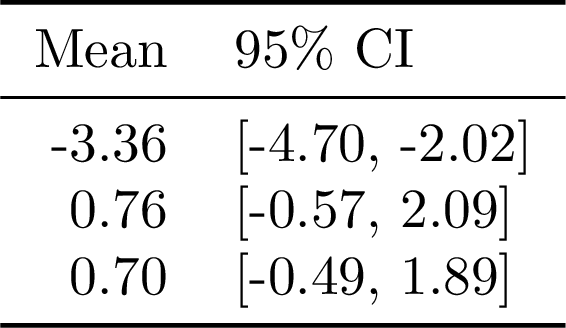

OK -> May_Presentation/tables/rendered/ny_v26_HSE_West_and_North_West_table.png

=== Combined NY summary ===
                   Region Period      Mean      2.5%     97.5%
  HSE Dublin and Midlands    Pre -2.304263 -3.225971 -1.381948
  HSE Dublin and Midlands    Mid -0.095732 -1.007860  0.819852
  HSE Dublin and Midlands   Post -0.020092 -0.840075  0.797277
HSE Dublin and North East    Pre -1.302635 -1.922554 -0.686617
HSE Dublin and North East    Mid -0.093475 -0.706689  0.523442
HSE Dublin and North East   Post  0.422630 -0.131162  0.976505
HSE Dublin and South East    Pre -1.314104 -2.037799 -0.592757
HSE Dublin and South East    Mid  0.043233 -0.674402  0.764049
HSE Dublin and South East   Post  0.058590 -0.591210  0.706401
             HSE Mid West    Pre -4.078569 -5.604711 -2.528196
             HSE Mid West    Mid -1.404644 -2.937556  0.137555
             HSE Mid West   Post -0.432634 -1.817774  0.947986
           HSE South West    Pre -2.810204 -4.006329 -1.604945
         

In [56]:
import sys
import numpy as np

sys.path.insert(0, str(PROJECT_ROOT))
from pyjags_pipeline.data import load_observed

raw_full = pd.read_csv(MODELS_DIR / FULL_VERSION / 'raw_samples.csv')
_, ny_regions, _, _, _ = load_observed('data/wide_weekly_scaledPer10k.csv')

PHASES = ['Pre', 'Mid', 'Post']
DELTA_COLS = ['delta_pre', 'delta_mid', 'delta_post']

LO_Q, HI_Q = 0.025, 0.975
VTAG = FULL_VERSION.replace('.', '')

ny_rows = []
for i, region in enumerate(ny_regions, start=1):
    means, lowers, uppers = [], [], []
    for col in DELTA_COLS:
        s = raw_full[f'{col}[{i}]'].values
        means.append(s.mean())
        lo, hi = np.quantile(s, [LO_Q, HI_Q])
        lowers.append(lo)
        uppers.append(hi)

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    yerr = [[m - l for m, l in zip(means, lowers)],
            [u - m for u, m in zip(uppers, means)]]
    ax.errorbar(range(3), means, yerr=yerr, fmt='-o',
                capsize=5, linewidth=2, markersize=8,
                label='95% CI')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(range(3))
    ax.set_xticklabels(PHASES)
    ax.set_xlabel('NY period')
    ax.set_ylabel('Effect (weekly trolleys per 10k)')
    ax.set_title(f'{region} — NY effect')
    ax.legend(loc='best', frameon=False)
    ax.grid(True, alpha=0.3)

    safe = region.replace(' ', '_')
    render_plot(f'ny_{VTAG}_{safe}', fig)

    region_df = pd.DataFrame({
        'Mean':   means,
        '2.5%':   lowers,
        '97.5%':  uppers,
    })
    region_df['95% CI'] = region_df.apply(
        lambda r: f"[{r['2.5%']:.2f}, {r['97.5%']:.2f}]", axis=1)
    display_region = region_df[['Mean', '95% CI']]
    print(f'\n=== {region} ===')
    print(display_region.to_string(index=False))

    body = (escape_df(display_region).style
            .format({'Mean': '{:.2f}'})
            .hide(axis='index')
            .to_latex(hrules=True, column_format='rl'))
    render_table(f'ny_{VTAG}_{safe}_table', body)

    for p, m, lo, hi in zip(PHASES, means, lowers, uppers):
        ny_rows.append({'Region': region, 'Period': p, 'Mean': m,
                        '2.5%': lo, '97.5%': hi})

ny_summary = pd.DataFrame(ny_rows)
print('\n=== Combined NY summary ===')
print(ny_summary.to_string(index=False))

## MCMC trace plot — $\alpha_1$

Trace + per-chain marginal density for the HSE Dublin and Midlands intercept $\alpha_1$. Four chains, 20{,}000 iterations each post burn-in. Well-mixed, hairy traces and overlapping densities are the visual sign of convergence; the Gelman-Rubin table below quantifies it across all parameters.

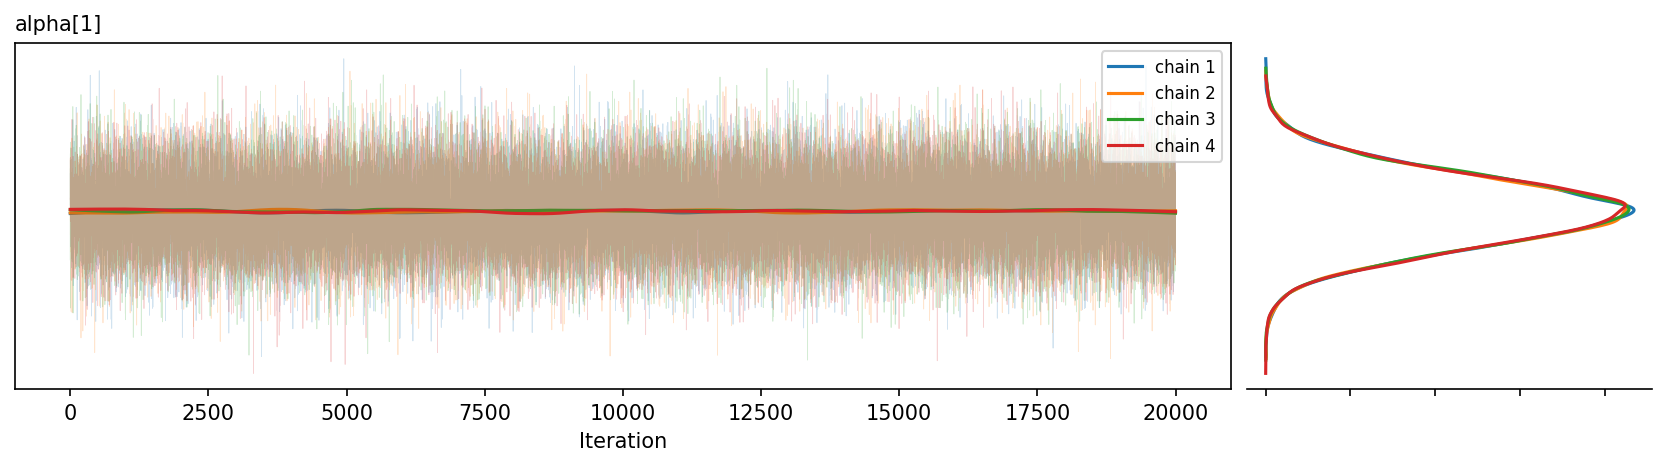

OK -> May_Presentation/tables/rendered/traces_v26_alpha1.png


In [57]:
import numpy as np
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

raw_traces = pd.read_csv(MODELS_DIR / FULL_VERSION / 'raw_samples.csv')
chain_ids = sorted(raw_traces['chain'].unique())

param = 'alpha[1]'  # HSE Dublin and Midlands intercept

fig, (ax_tr, ax_kd) = plt.subplots(
    1, 2, figsize=(11, 3),
    gridspec_kw={'width_ratios': [3, 1]},
    layout='constrained',
)
ax_kd.sharey(ax_tr)

for c_idx, ch in enumerate(chain_ids):
    vals = raw_traces.loc[raw_traces['chain'] == ch, param].values
    x = np.arange(len(vals))
    color = f'C{c_idx}'
    ax_tr.plot(x, vals, alpha=0.2, lw=0.4, color=color)
    smooth = lowess(vals, x, frac=0.1, return_sorted=True)
    ax_tr.plot(smooth[:, 0], smooth[:, 1], color=color, lw=1.5,
               label=f'chain {ch}')
    kde = gaussian_kde(vals)
    y_grid = np.linspace(vals.min(), vals.max(), 300)
    ax_kd.plot(kde(y_grid), y_grid, color=color, lw=1.5)

ax_tr.set_title(param, fontsize=10, loc='left')
ax_tr.set_xlabel('Iteration')
ax_tr.legend(loc='upper right', fontsize=8)
ax_kd.tick_params(left=False, labelleft=False, labelbottom=False)
for s in ('left', 'right', 'top'):
    ax_kd.spines[s].set_visible(False)
ax_kd.set_yticks([])

render_plot(f'traces_{FULL_VERSION.replace(".", "")}_alpha1', fig)

## Gelman-Rubin convergence

$\hat{R}$ for every monitored scalar of the full model. Values $\le 1.1$ indicate between-chain variance is negligible relative to within-chain variance (Gelman & Rubin 1992); all parameters are far below that threshold.

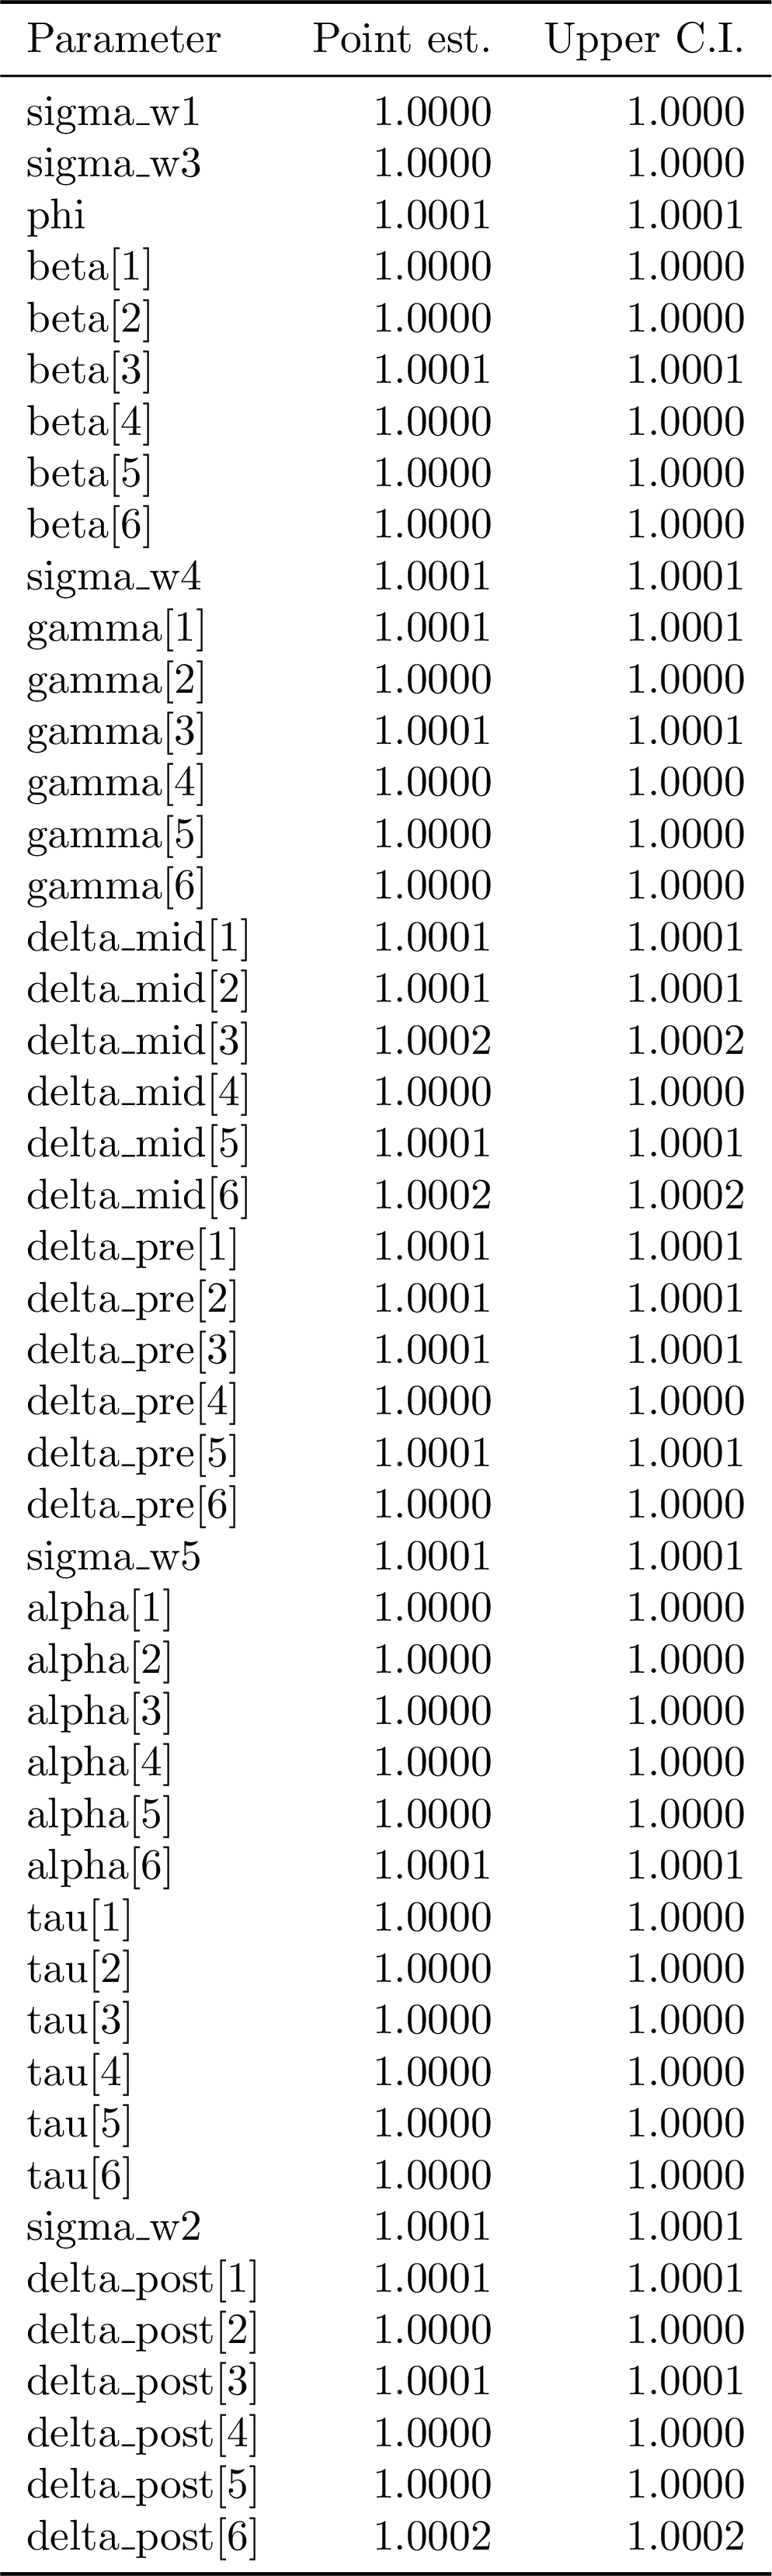

OK -> May_Presentation/tables/rendered/gelman_v26.png


In [58]:
gelman = pd.read_csv(MODELS_DIR / FULL_VERSION / 'gelman.csv')
gelman.columns = ['Parameter', 'Point est.', 'Upper C.I.']
gelman = escape_df(gelman)

body = (gelman.style
        .format({'Point est.': '{:.4f}', 'Upper C.I.': '{:.4f}'})
        .hide(axis='index')
        .to_latex(hrules=True, column_format='lrr'))

render_table(f'gelman_{FULL_VERSION.replace(".", "")}', body)

## Add another table

Pattern: load CSV -> `pd.DataFrame.style...to_latex(hrules=True, column_format=...)` -> `render_table('name', body)`.

Useful CSVs already produced per model run:

- `global_parameters.csv` -- global scalar posteriors
- `ranks.csv` -- regional alpha ranking
- `sigma_overall.csv` -- Mid-West reset effect summary (only present for V2.x+)
- `gelman_summary.csv` -- max R-hat per parameter group

**Column format hints (siunitx `S` aligns numbers on the decimal point):**
- All-text: `'l' * n_cols`
- Mixed: `'l' + 'S' * (n_cols - 1)` (label column + numeric)
- For wide numbers, adjust the preamble's `\sisetup{table-format=...}`